# Business Understanding

## FedEx Fuel Consumption and Price Forecasting

### Business Understanding

#### Business Problem

Fuel is a major operating cost for transportation and logistics companies such as FedEx. Changes in fuel consumption and fuel prices can therefore affect operational costs and overall business performance.

The objective of this project is to use historical fuel and related data to predict future fuel requirements and fuel prices.

#### Main Questions

1. Can we predict FedEx's fuel consumption for the following week using historical fuel consumption data?
2. Can we predict the following week's fuel price using historical fuel prices and crude oil prices?
3. How strongly is FedEx fuel cost related to crude oil and other fuel prices?
4. Which historical and external variables are most useful for predicting future fuel consumption and price?

#### Project Objectives

The project will:

- Analyze historical fuel consumption and fuel price trends.
- Investigate relationships between crude oil, fuel prices and FedEx fuel consumption.
- Create time-based and lagged features from historical data.
- Establish simple forecasting baselines.
- Train and compare machine learning/time-series models.
- Evaluate the models using appropriate forecasting metrics.
- Forecast the next week's fuel consumption and fuel price.
- Interpret the factors contributing to the forecasts.

#### Target Variables

The primary targets will be:

- Future fuel consumption
- Future fuel price

The exact target columns will be determined after inspecting the dataset.

#### Success Criteria

A successful model should perform better than a simple baseline forecast and provide useful predictions without using information that would not have been available at the time of prediction.

## 2. Importing Libraries

The following libraries will be used for data manipulation, visualization, statistical analysis and machine learning.

We will initially import only the libraries needed for data understanding and exploration. Additional libraries will be added later when required.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Loading the Datasets

This project uses multiple datasets from different sources. Each dataset provides information that will contribute to understanding and forecasting fuel consumption and fuel prices.

The main datasets are:

1. **WTI Crude Oil Prices**
   - Provides daily West Texas Intermediate (WTI) crude oil prices.
   - Used as a macroeconomic indicator of movements in the oil market.

2. **FedEx International Fuel Surcharge**
   - Provides historical FedEx international fuel surcharge rates and the corresponding jet fuel price ranges.
   - Used to investigate the relationship between fuel prices and FedEx pricing.

3. **EIA State Fuel Prices**
   - Provides weekly retail gasoline and diesel prices by U.S. state.
   - Used to represent ground transportation fuel costs.

4. **California Household Travel Survey**
   - Provides household, vehicle and travel information.
   - May be used as a proxy for vehicle usage, travel distance and fuel-consumption patterns.

At this stage, the datasets will be loaded independently. No cleaning, transformation or merging will be performed until the structure and quality of each dataset have been understood.

In [2]:
DCOILWTICO_df = "../data/raw/DCOILWTICO.csv"
international_fuel_surcharge_df = "../data/raw/international-fuel-surcharge.csv"
state_prices_df = "../data/raw/state-prices.csv"

wti_df = pd.read_csv(DCOILWTICO_df)
fuel_surcharge_df = pd.read_csv(international_fuel_surcharge_df)
state_prices_df = pd.read_csv(state_prices_df)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [3]:
jet_fuel_weekly_path = "../data/raw/WJFUELUSGULF.csv"
jet_fuel_daily_path = "../data/raw/DJFUELUSGULF.csv"
diesel_weekly_path = "../data/raw/GASDESLSW.csv"

jet_fuel_weekly_df = pd.read_csv(jet_fuel_weekly_path)
jet_fuel_daily_df = pd.read_csv(jet_fuel_daily_path)
diesel_weekly_df = pd.read_csv(diesel_weekly_path)

print("Additional fuel datasets loaded successfully.")

Additional fuel datasets loaded successfully.


In [4]:
print("WTI Crude Oil Prices:")
display(wti_df.head())

print("\nFedEx International Fuel Surcharge:")
display(fuel_surcharge_df.head())

print("\nEIA State Fuel Prices:")
display(state_prices_df.head())

WTI Crude Oil Prices:


,observation_date,DCOILWTICO
0,2021-09-09,68.26
1,2021-09-10,69.82
2,2021-09-13,70.54
3,2021-09-14,70.53
4,2021-09-15,72.59



FedEx International Fuel Surcharge:


,Week,Week Price,Surcharge
0,"14 September, 2026 - 20 September, 2026",$4.08,49.00%
1,"07 September, 2026 - 13 September, 2026",$3.72,46.00%
2,"31 August, 2026 - 06 September, 2026",$3.92,47.75%
3,"24 August, 2026 - 30 August, 2026",$3.77,46.50%
4,"17 August, 2026 - 23 August, 2026",$3.43,43.50%



EIA State Fuel Prices:


,state,abbr,slug,padd,regular_price,regular_basis,regular_eia_area,regular_series,diesel_price,diesel_basis,diesel_eia_area,diesel_series,survey_week
0,Connecticut,CT,connecticut,1,4.096,region,New England (PADD 1A),EMM_EPMR_PTE_R1X_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31
1,Maine,ME,maine,1,4.096,region,New England (PADD 1A),EMM_EPMR_PTE_R1X_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31
2,Massachusetts,MA,massachusetts,1,4.068,state,Massachusetts,EMM_EPMR_PTE_SMA_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31
3,New Hampshire,NH,new-hampshire,1,4.096,region,New England (PADD 1A),EMM_EPMR_PTE_R1X_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31
4,Rhode Island,RI,rhode-island,1,4.096,region,New England (PADD 1A),EMM_EPMR_PTE_R1X_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31


In [5]:
print("Weekly Jet Fuel:", jet_fuel_weekly_df.shape)
print("Daily Jet Fuel:", jet_fuel_daily_df.shape)
print("Weekly Diesel:", diesel_weekly_df.shape)

print("\nWeekly Jet Fuel columns:")
print(jet_fuel_weekly_df.columns.tolist())

print("\nDaily Jet Fuel columns:")
print(jet_fuel_daily_df.columns.tolist())

print("\nWeekly Diesel columns:")
print(diesel_weekly_df.columns.tolist())

Weekly Jet Fuel: (1901, 2)
Daily Jet Fuel: (1305, 2)
Weekly Diesel: (1024, 2)

Weekly Jet Fuel columns:
['observation_date', 'WJFUELUSGULF']

Daily Jet Fuel columns:
['observation_date', 'DJFUELUSGULF']

Weekly Diesel columns:
['observation_date', 'GASDESLSW']


In [6]:
display(jet_fuel_weekly_df.head())
display(jet_fuel_daily_df.head())
display(diesel_weekly_df.head())

,observation_date,WJFUELUSGULF
0,1990-04-06,0.548
1,1990-04-13,0.540
2,1990-04-20,0.543
3,1990-04-27,0.530
4,1990-05-04,0.522


,observation_date,DJFUELUSGULF
0,2021-09-09,1.893
1,2021-09-10,1.922
2,2021-09-13,1.955
3,2021-09-14,1.965
4,2021-09-15,2.015


,observation_date,GASDESLSW
0,2007-02-05,2.463
1,2007-02-12,2.502
2,2007-02-19,2.515
3,2007-02-26,2.571
4,2007-03-05,2.640


In [7]:
print("Weekly Jet Fuel")
print(jet_fuel_weekly_df.tail())

print("\nDaily Jet Fuel")
print(jet_fuel_daily_df.tail())

print("\nWeekly Diesel")
print(diesel_weekly_df.tail())

Weekly Jet Fuel
     observation_date  WJFUELUSGULF
1896       2026-08-07         3.431
1897       2026-08-14         3.770
1898       2026-08-21         3.922
1899       2026-08-28         3.715
1900       2026-09-04         4.082

Daily Jet Fuel
     observation_date  DJFUELUSGULF
1300       2026-09-03         4.063
1301       2026-09-04         4.017
1302       2026-09-07           NaN
1303       2026-09-08         4.126
1304       2026-09-09         4.341

Weekly Diesel
     observation_date  GASDESLSW
1019       2026-08-17      5.454
1020       2026-08-24      5.652
1021       2026-08-31      5.599
1022       2026-09-07      5.967
1023       2026-09-14      6.285


### 3.1 Initial Dataset Structure

The datasets originate from different sources and therefore may have different structures, column names, date formats and levels of aggregation.

We will inspect the shape and columns of each dataset before proceeding with data preparation.

This allows us to determine:

- The number of observations and variables.
- The variables available for analysis.
- The time period covered.
- The level of aggregation.
- Which variables may be useful for forecasting.

In [8]:
print("WTI dataset shape:", wti_df.shape)
print("WTI columns:")
print(wti_df.columns.tolist())

print("\nFedEx fuel surcharge dataset shape:", fuel_surcharge_df.shape)
print("FedEx fuel surcharge columns:")
print(fuel_surcharge_df.columns.tolist())

print("\nState fuel prices dataset shape:", state_prices_df.shape)
print("State fuel prices columns:")
print(state_prices_df.columns.tolist())

WTI dataset shape: (1305, 2)
WTI columns:
['observation_date', 'DCOILWTICO']

FedEx fuel surcharge dataset shape: (13, 3)
FedEx fuel surcharge columns:
['Week', 'Week Price', 'Surcharge']

State fuel prices dataset shape: (51, 13)
State fuel prices columns:
['state', 'abbr', 'slug', 'padd', 'regular_price', 'regular_basis', 'regular_eia_area', 'regular_series', 'diesel_price', 'diesel_basis', 'diesel_eia_area', 'diesel_series', 'survey_week']


### 3.2 Dataset Information

We will examine the data types and non-null counts for each dataset.

This is an initial data-understanding step. We will not modify the data yet.

In [9]:
print("WTI Dataset Information")
wti_df.info()

print("\n" + "="*60 + "\n")

print("FedEx Fuel Surcharge Dataset Information")
fuel_surcharge_df.info()

print("\n" + "="*60 + "\n")

print("State Fuel Prices Dataset Information")
state_prices_df.info()

WTI Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 1305 entries, 0 to 1304
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  1305 non-null   str    
 1   DCOILWTICO        1248 non-null   float64
dtypes: float64(1), str(1)
memory usage: 20.5 KB


FedEx Fuel Surcharge Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Week        13 non-null     str  
 1   Week Price  13 non-null     str  
 2   Surcharge   13 non-null     str  
dtypes: str(3)
memory usage: 444.0 bytes


State Fuel Prices Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   state             51 non-null     str    
 

### 3.3 Previewing the Datasets

The first few observations provide an initial view of how the variables are represented.

We will inspect both the beginning and end of each dataset to understand the chronological coverage and identify any obvious structural differences.

In [10]:
print("WTI - First 5 rows")
display(wti_df.head())

print("WTI - Last 5 rows")
display(wti_df.tail())

print("FedEx Fuel Surcharge - First 5 rows")
display(fuel_surcharge_df.head())

print("FedEx Fuel Surcharge - Last 5 rows")
display(fuel_surcharge_df.tail())

print("State Prices - First 5 rows")
display(state_prices_df.head())

print("State Prices - Last 5 rows")
display(state_prices_df.tail())

WTI - First 5 rows


,observation_date,DCOILWTICO
0,2021-09-09,68.26
1,2021-09-10,69.82
2,2021-09-13,70.54
3,2021-09-14,70.53
4,2021-09-15,72.59


WTI - Last 5 rows


,observation_date,DCOILWTICO
1300,2026-09-03,92.55
1301,2026-09-04,92.69
1302,2026-09-07,NaN
1303,2026-09-08,94.21
1304,2026-09-09,97.26


FedEx Fuel Surcharge - First 5 rows


...

,Week,Week Price,Surcharge
8,"20 July, 2026 - 26 July, 2026",$2.97,39.75%
9,"13 July, 2026 - 19 July, 2026",$2.82,38.50%
10,"06 July, 2026 - 12 July, 2026",$2.79,38.25%
11,"29 June, 2026 - 05 July, 2026",$2.84,38.50%
12,"22 June, 2026 - 28 June, 2026",$3.19,41.50%


State Prices - First 5 rows


,state,abbr,slug,padd,regular_price,regular_basis,regular_eia_area,regular_series,diesel_price,diesel_basis,diesel_eia_area,diesel_series,survey_week
0,Connecticut,CT,connecticut,1,4.096,region,New England (PADD 1A),EMM_EPMR_PTE_R1X_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31
1,Maine,ME,maine,1,4.096,region,New England (PADD 1A),EMM_EPMR_PTE_R1X_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31
2,Massachusetts,MA,massachusetts,1,4.068,state,Massachusetts,EMM_EPMR_PTE_SMA_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31
3,New Hampshire,NH,new-hampshire,1,4.096,region,New England (PADD 1A),EMM_EPMR_PTE_R1X_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31
4,Rhode Island,RI,rhode-island,1,4.096,region,New England (PADD 1A),EMM_EPMR_PTE_R1X_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31


State Prices - Last 5 rows


,state,abbr,slug,padd,regular_price,regular_basis,regular_eia_area,regular_series,diesel_price,diesel_basis,diesel_eia_area,diesel_series,survey_week
46,California,CA,california,5,5.520,state,California,EMM_EPMR_PTE_SCA_DPG,7.218,state,California,EMD_EPD2D_PTE_SCA_DPG,2026-08-31
47,Hawaii,HI,hawaii,5,4.823,region,West Coast less California,EMM_EPMR_PTE_R5XCA_DPG,5.872,region,West Coast less California,EMD_EPD2D_PTE_R5XCA_DPG,2026-08-31
48,Nevada,NV,nevada,5,4.823,region,West Coast less California,EMM_EPMR_PTE_R5XCA_DPG,5.872,region,West Coast less California,EMD_EPD2D_PTE_R5XCA_DPG,2026-08-31
49,Oregon,OR,oregon,5,4.823,region,West Coast less California,EMM_EPMR_PTE_R5XCA_DPG,5.872,region,West Coast less California,EMD_EPD2D_PTE_R5XCA_DPG,2026-08-31
50,Washington,WA,washington,5,5.259,state,Washington,EMM_EPMR_PTE_SWA_DPG,5.872,region,West Coast less California,EMD_EPD2D_PTE_R5XCA_DPG,2026-08-31


## 4 Data Understanding

### 4.1 WTI Crude Oil Dataset

The WTI dataset contains daily crude oil spot prices from September 2021 onward.

It contains two variables:

- `observation_date`: Date of the observation.
- `DCOILWTICO`: WTI crude oil spot price in U.S. dollars per barrel.

The dataset contains 1,305 observations. There are 1,248 non-null price observations, meaning that 57 observations contain missing WTI prices.

Because this is a time-series dataset, the date variable will be particularly important for ordering observations and creating future forecasting features.

In [11]:
wti_df.head()

,observation_date,DCOILWTICO
0,2021-09-09,68.26
1,2021-09-10,69.82
2,2021-09-13,70.54
3,2021-09-14,70.53
4,2021-09-15,72.59


In [12]:
wti_df["DCOILWTICO"].describe()

count    1248.000000
mean       79.265673
std        13.316883
min        55.440000
25%        70.090000
50%        77.670000
75%        86.000000
max       123.640000
Name: DCOILWTICO, dtype: float64

#### 4.1.1 WTI Date Range

We will determine the period covered by the WTI dataset.

Understanding the time span is important because forecasting models require sufficient historical observations to learn trends, patterns and changes over time.

In [13]:
wti_df["observation_date"] = pd.to_datetime(wti_df["observation_date"])

print("Start date:", wti_df["observation_date"].min())
print("End date:", wti_df["observation_date"].max())

Start date: 2021-09-09 00:00:00
End date: 2026-09-09 00:00:00


#### 4.1.2 Missing Values in WTI Prices

The WTI dataset contains missing price observations.

Before deciding how to handle these missing values, we will investigate when they occur and whether they correspond to non-trading days or other gaps in the time series.

Missing observations should not automatically be removed or filled without first understanding their cause.

In [14]:
wti_df[wti_df["DCOILWTICO"].isna()].head(20)

,observation_date,DCOILWTICO
55,2021-11-25,NaN
56,2021-11-26,NaN
76,2021-12-24,NaN
92,2022-01-17,NaN
117,2022-02-21,NaN
156,2022-04-15,NaN
187,2022-05-30,NaN
202,2022-06-20,NaN
212,2022-07-04,NaN
257,2022-09-05,NaN


In [15]:
print("Total missing WTI prices:", wti_df["DCOILWTICO"].isna().sum())

Total missing WTI prices: 57


#### 4.1.3 WTI Observation Frequency

The WTI dataset is recorded at a daily frequency.

Our final forecasting problem is focused on weekly fuel consumption and fuel prices. Therefore, WTI will eventually need to be aligned with the weekly datasets.

Before performing this transformation, we will examine the distribution of observations across dates and identify gaps caused by weekends and market holidays.

In [16]:
wti_df["observation_date"].diff().value_counts().head(10)

observation_date
1 days    1043
3 days     261
Name: count, dtype: int64

#### 4.1.4 WTI Crude Oil Price Trend

A time-series plot will be used to visualize how WTI crude oil prices have changed over the period covered by the dataset.

This will help us identify:

- Overall trends
- Periods of high and low prices
- Sudden price movements
- Potential outliers
- Changes in volatility

Understanding these patterns will help determine which transformations and forecasting features may be useful later.

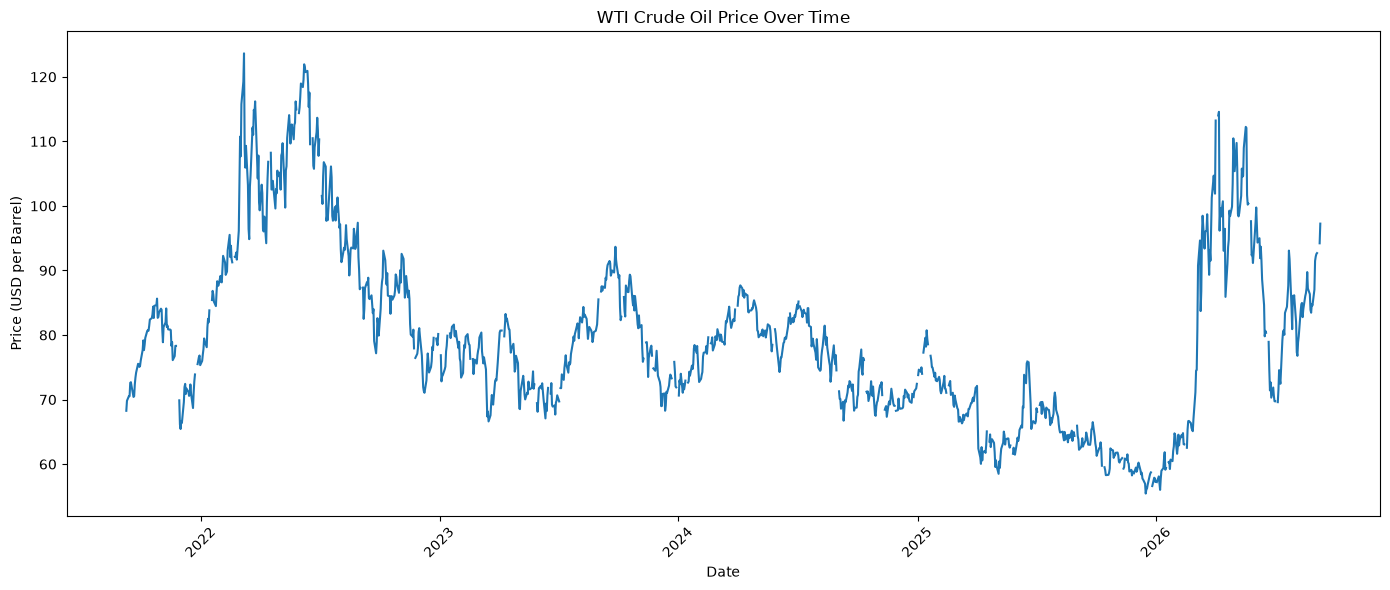

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    wti_df["observation_date"],
    wti_df["DCOILWTICO"]
)

plt.title("WTI Crude Oil Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD per Barrel)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#### 4.1.5 WTI Price Distribution

A distribution plot will help us understand how frequently different WTI price levels occur.

This will allow us to identify the typical price range and investigate whether extreme price observations exist.

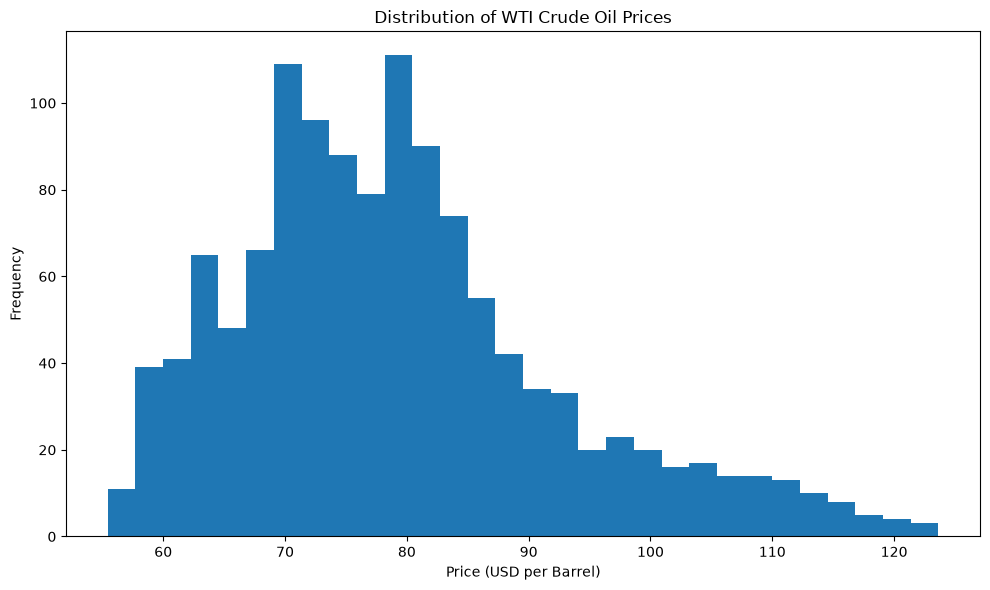

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(
    wti_df["DCOILWTICO"].dropna(),
    bins=30
)

plt.title("Distribution of WTI Crude Oil Prices")
plt.xlabel("Price (USD per Barrel)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#### 4.1.6 Investigating Extreme WTI Prices

The descriptive statistics indicate substantial variation in WTI prices.

Instead of automatically treating extreme observations as errors or outliers, we will identify their dates and investigate whether they represent genuine market movements.

In a financial or commodity time series, extreme observations can contain important information and should not automatically be removed.

In [19]:
print("Lowest WTI prices:")
display(
    wti_df.nsmallest(10, "DCOILWTICO")
)

print("\nHighest WTI prices:")
display(
    wti_df.nlargest(10, "DCOILWTICO")
)

Lowest WTI prices:


,observation_date,DCOILWTICO
1113,2025-12-16,55.44
1129,2026-01-07,56.01
1114,2025-12-17,56.07
1115,2025-12-18,56.22
1121,2025-12-26,56.60
1116,2025-12-19,56.80
1112,2025-12-15,56.97
1128,2026-01-06,56.97
1126,2026-01-02,57.21
1124,2025-12-31,57.26



Highest WTI prices:


,observation_date,DCOILWTICO
128,2022-03-08,123.64
194,2022-06-08,121.94
195,2022-06-09,121.52
197,2022-06-13,120.92
196,2022-06-10,120.73
193,2022-06-07,119.55
127,2022-03-07,119.26
191,2022-06-03,118.97
198,2022-06-14,118.92
192,2022-06-06,118.41


### 4.2 FedEx International Fuel Surcharge Dataset

The FedEx International Fuel Surcharge dataset contains weekly observations linking a published U.S. Gulf Coast jet fuel price with the corresponding FedEx international fuel surcharge.

The dataset currently contains 13 weekly observations.

Because 13 observations are insufficient for training a reliable time-series forecasting model, this dataset will not be treated as the primary forecasting dataset.

Instead, it will initially be used to investigate the relationship between jet fuel prices and FedEx fuel surcharges.

If a longer historical FedEx surcharge dataset can be obtained, it may later be incorporated into the analysis.

In [20]:
display(fuel_surcharge_df)

,Week,Week Price,Surcharge
0,"14 September, 2026 - 20 September, 2026",$4.08,49.00%
1,"07 September, 2026 - 13 September, 2026",$3.72,46.00%
2,"31 August, 2026 - 06 September, 2026",$3.92,47.75%
3,"24 August, 2026 - 30 August, 2026",$3.77,46.50%
4,"17 August, 2026 - 23 August, 2026",$3.43,43.50%
5,"10 August, 2026 - 16 August, 2026",$3.74,46.00%
6,"03 August, 2026 - 09 August, 2026",$3.68,45.50%
7,"27 July, 2026 - 02 August, 2026",$3.50,44.00%
8,"20 July, 2026 - 26 July, 2026",$2.97,39.75%
9,"13 July, 2026 - 19 July, 2026",$2.82,38.50%


In [21]:
print("Shape:", fuel_surcharge_df.shape)

print("\nColumns:")
print(fuel_surcharge_df.columns.tolist())

print("\nData types:")
print(fuel_surcharge_df.dtypes)

Shape: (13, 3)

Columns:
['Week', 'Week Price', 'Surcharge']

Data types:
Week          str
Week Price    str
Surcharge     str
dtype: object


In [22]:
fuel_surcharge_df.isnull().sum()

Week          0
Week Price    0
Surcharge     0
dtype: int64

In [23]:
print("First observation:")
print(fuel_surcharge_df.iloc[0])

print("\nLast observation:")
print(fuel_surcharge_df.iloc[-1])

First observation:
Week          14 September, 2026 - 20 September, 2026
Week Price                                     $4.08 
Surcharge                                      49.00%
Name: 0, dtype: str

Last observation:
Week          22 June, 2026 - 28 June, 2026
Week Price                           $3.19 
Surcharge                            41.50%
Name: 12, dtype: str


### 4.3 EIA State Fuel Prices

The EIA dataset contains gasoline and diesel prices for 50 U.S. states and Washington D.C.

The dataset currently contains 51 observations corresponding to a single survey week.

Therefore, it cannot currently be used to model weekly fuel-price trends.

However, it provides useful information about the geographic variation in gasoline and diesel prices.

For the forecasting stage, a longer historical weekly EIA dataset will be required.

In [24]:
state_prices_df.describe()

,padd,regular_price,diesel_price
count,51.000000,51.000000,51.000000
mean,2.372549,4.069000,5.628431
std,1.413659,0.424192,0.298986
min,1.000000,3.577000,5.276000
25%,1.000000,3.836000,5.555000
50%,2.000000,3.847000,5.571000
75%,3.000000,4.121500,5.787000
max,5.000000,5.520000,7.218000


### 4.3.1 State Diesel Price Distribution

Diesel is an important fuel for ground transportation.

We will examine the distribution of diesel prices across the states to understand the geographic variation in fuel costs.

In [25]:
state_prices_df["diesel_price"].describe()

count    51.000000
mean      5.628431
std       0.298986
min       5.276000
25%       5.555000
50%       5.571000
75%       5.787000
max       7.218000
Name: diesel_price, dtype: float64

In [26]:
state_prices_df[
    ["state", "abbr", "diesel_price"]
].sort_values("diesel_price", ascending=False).head(10)

,state,abbr,diesel_price
46,California,CA,7.218
50,Washington,WA,5.872
45,Arizona,AZ,5.872
49,Oregon,OR,5.872
44,Alaska,AK,5.872
48,Nevada,NV,5.872
47,Hawaii,HI,5.872
10,New York,NY,5.838
8,Maryland,MD,5.838
9,New Jersey,NJ,5.838


In [27]:
state_prices_df[
    ["state", "abbr", "diesel_price"]
].sort_values("diesel_price").head(10)

,state,abbr,diesel_price
12,Florida,FL,5.276
13,Georgia,GA,5.276
14,North Carolina,NC,5.276
15,South Carolina,SC,5.276
17,West Virginia,WV,5.276
16,Virginia,VA,5.276
34,Arkansas,AR,5.360
33,Alabama,AL,5.360
36,Mississippi,MS,5.360
35,Louisiana,LA,5.360


### 4.4 Weekly Jet Fuel Dataset

The weekly jet fuel dataset contains historical U.S. Gulf Coast kerosene-type jet fuel spot prices in USD per gallon.

This dataset is important for the project because the final analysis will investigate the relationship between crude oil prices, jet fuel prices and FedEx fuel-related costs.

The dataset contains weekly observations from 1990 to 2026, providing a substantial historical period for time-series analysis and forecasting.

In [28]:
jet_fuel_weekly_df.head()

,observation_date,WJFUELUSGULF
0,1990-04-06,0.548
1,1990-04-13,0.540
2,1990-04-20,0.543
3,1990-04-27,0.530
4,1990-05-04,0.522


#### 4.4.1 Weekly Jet Fuel Descriptive Statistics

We examine the statistical distribution of weekly jet fuel prices, including the average price, variation and minimum and maximum values.

In [29]:
jet_fuel_weekly_df["WJFUELUSGULF"].describe()

count    1901.000000
mean        1.583945
std         0.961441
min         0.294000
25%         0.646000
50%         1.506000
75%         2.195000
max         4.626000
Name: WJFUELUSGULF, dtype: float64

#### 4.4.2 Weekly Jet Fuel Date Range

We identify the period covered by the weekly jet fuel dataset to understand the available historical forecasting window.

In [30]:
jet_fuel_weekly_df["observation_date"] = pd.to_datetime(
    jet_fuel_weekly_df["observation_date"]
)

print("Start date:", jet_fuel_weekly_df["observation_date"].min())
print("End date:", jet_fuel_weekly_df["observation_date"].max())

Start date: 1990-04-06 00:00:00
End date: 2026-09-04 00:00:00


#### 4.4.3 Missing Values in Weekly Jet Fuel

We check whether the weekly jet fuel price series contains missing observations before proceeding to further analysis.

In [31]:
print(
    "Missing weekly jet fuel prices:",
    jet_fuel_weekly_df["WJFUELUSGULF"].isna().sum()
)

Missing weekly jet fuel prices: 0


#### 4.4.4 Weekly Jet Fuel Observation Frequency

We examine the differences between consecutive observation dates to verify the frequency of the dataset.

In [32]:
jet_fuel_weekly_df["observation_date"].diff().value_counts().head(10)

observation_date
7 days    1900
Name: count, dtype: int64

#### 4.4.5 Weekly Jet Fuel Price Trend

We visualize the historical movement of weekly jet fuel prices at the U.S. Gulf Coast.

The purpose is to identify long-term trends, major price movements, periods of high volatility and potential extreme observations.

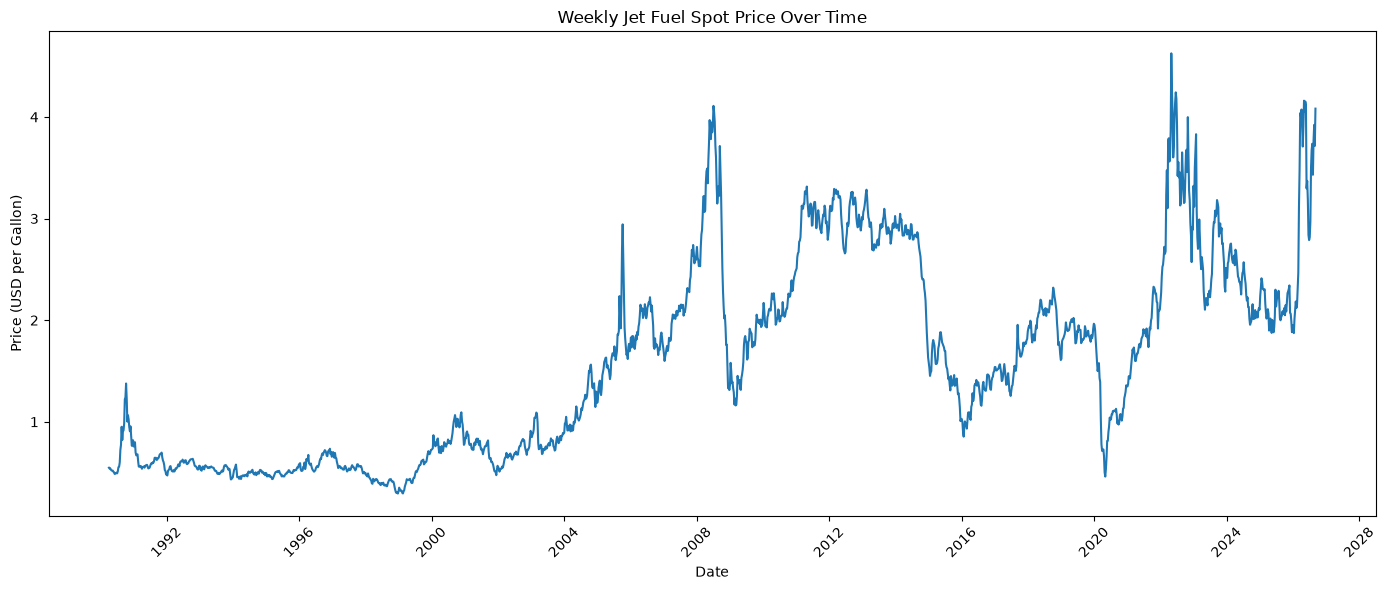

In [33]:
plt.figure(figsize=(14, 6))

plt.plot(
    jet_fuel_weekly_df["observation_date"],
    jet_fuel_weekly_df["WJFUELUSGULF"]
)

plt.title("Weekly Jet Fuel Spot Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD per Gallon)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

I am now going to repeat the same procedure for the other two datasets

### 4.5 Daily Jet fuel Dataset

In [34]:
jet_fuel_daily_df.head()


,observation_date,DJFUELUSGULF
0,2021-09-09,1.893
1,2021-09-10,1.922
2,2021-09-13,1.955
3,2021-09-14,1.965
4,2021-09-15,2.015


In [35]:
jet_fuel_daily_df["DJFUELUSGULF"].describe()



count    1247.000000
mean        2.694286
std         0.664962
min         1.819000
25%         2.154000
50%         2.481000
75%         3.125500
max         5.066000
Name: DJFUELUSGULF, dtype: float64

In [36]:
jet_fuel_daily_df["observation_date"] = pd.to_datetime(
    jet_fuel_daily_df["observation_date"]
)

print("Start date:", jet_fuel_daily_df["observation_date"].min())
print("End date:", jet_fuel_daily_df["observation_date"].max())



Start date: 2021-09-09 00:00:00
End date: 2026-09-09 00:00:00


In [37]:
print(
    "Missing daily jet fuel prices:",
    jet_fuel_daily_df["DJFUELUSGULF"].isna().sum()
)



Missing daily jet fuel prices: 58


In [38]:
jet_fuel_daily_df["observation_date"].diff().value_counts().head(10)

observation_date
1 days    1043
3 days     261
Name: count, dtype: int64

### 4.6 Diesel Weekly Dataset

In [39]:
diesel_weekly_df.head()

,observation_date,GASDESLSW
0,2007-02-05,2.463
1,2007-02-12,2.502
2,2007-02-19,2.515
3,2007-02-26,2.571
4,2007-03-05,2.640


In [40]:
diesel_weekly_df["GASDESLSW"].describe()

count    1024.000000
mean        3.433944
std         0.795270
min         1.980000
25%         2.833500
50%         3.369500
75%         3.907250
max         6.285000
Name: GASDESLSW, dtype: float64

In [41]:
diesel_weekly_df["observation_date"] = pd.to_datetime(
    diesel_weekly_df["observation_date"]
)

print("Start date:", diesel_weekly_df["observation_date"].min())
print("End date:", diesel_weekly_df["observation_date"].max())

Start date: 2007-02-05 00:00:00
End date: 2026-09-14 00:00:00


In [42]:
print(
    "Missing weekly diesel prices:",
    diesel_weekly_df["GASDESLSW"].isna().sum()
)

Missing weekly diesel prices: 0


In [43]:
diesel_weekly_df["observation_date"].diff().value_counts().head(10)

observation_date
7 days    1023
Name: count, dtype: int64

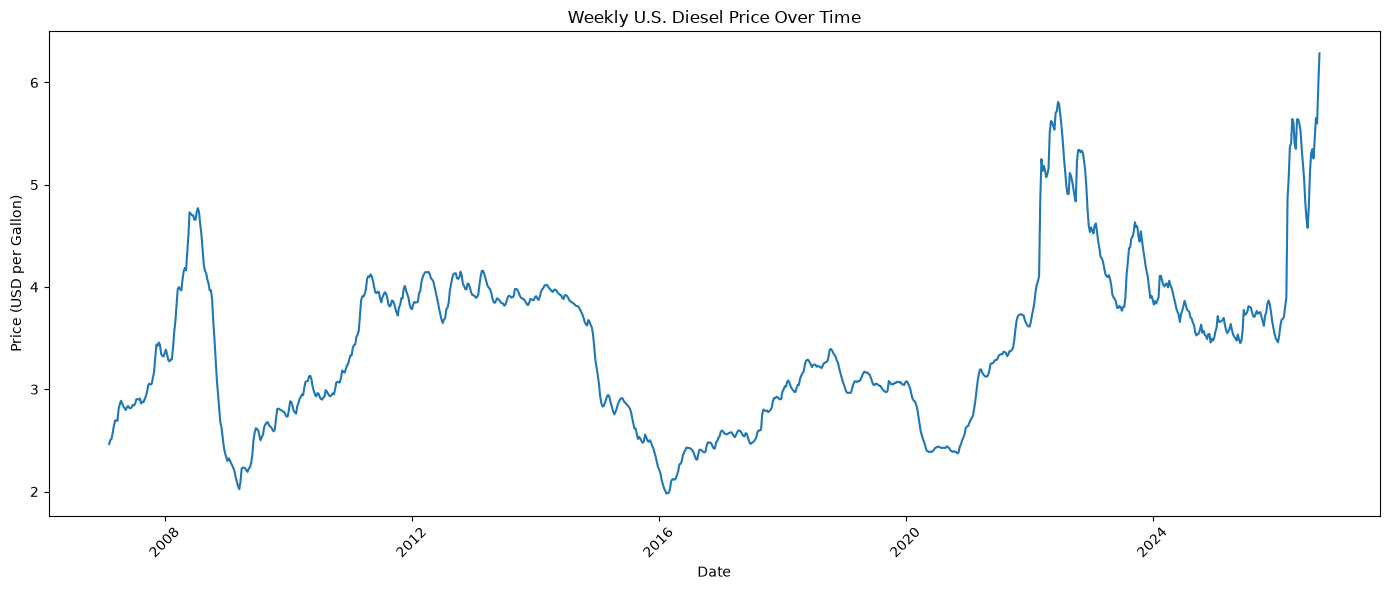

In [44]:
plt.figure(figsize=(14, 6))

plt.plot(
    diesel_weekly_df["observation_date"],
    diesel_weekly_df["GASDESLSW"]
)

plt.title("Weekly U.S. Diesel Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD per Gallon)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Comparison of Weekly Jet Fuel and Diesel Prices

We compare the historical movements of weekly jet fuel and diesel prices.

The purpose is to determine whether the two fuel markets appear to move together over time and to identify periods where their movements differ.

This comparison is descriptive only. Statistical relationships and lagged effects will be tested later during exploratory analysis and feature engineering.

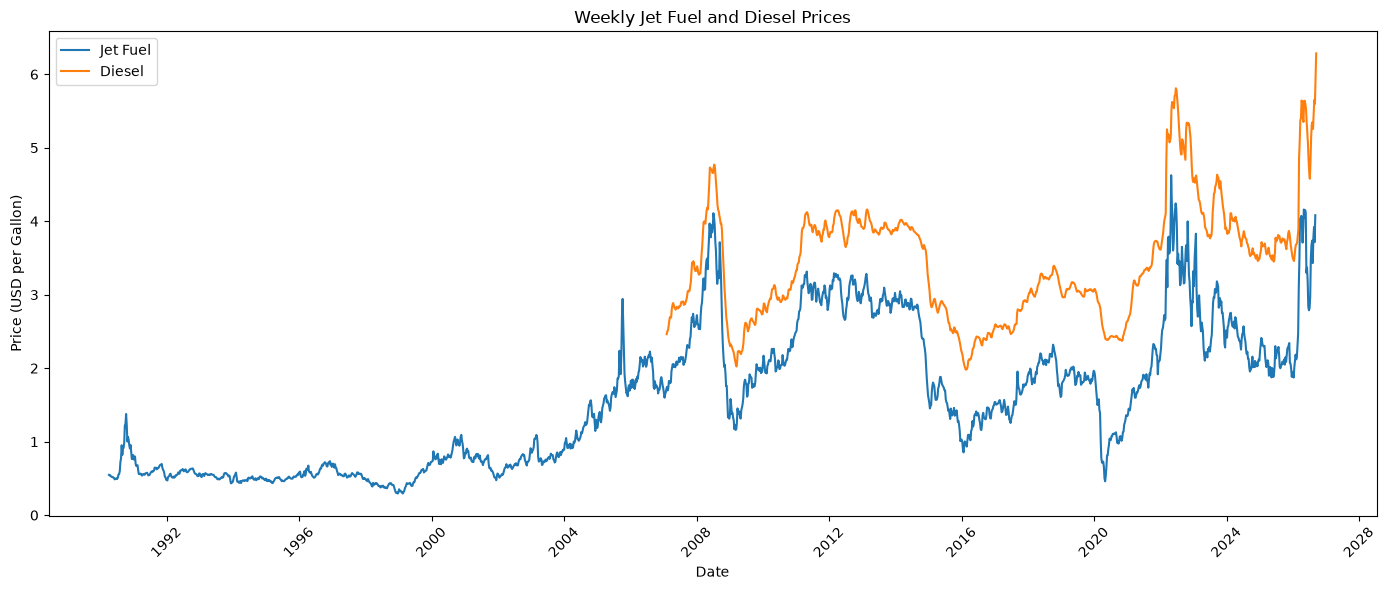

In [45]:
plt.figure(figsize=(14, 6))

plt.plot(
    jet_fuel_weekly_df["observation_date"],
    jet_fuel_weekly_df["WJFUELUSGULF"],
    label="Jet Fuel"
)

plt.plot(
    diesel_weekly_df["observation_date"],
    diesel_weekly_df["GASDESLSW"],
    label="Diesel"
)

plt.title("Weekly Jet Fuel and Diesel Prices")
plt.xlabel("Date")
plt.ylabel("Price (USD per Gallon)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Data Preparation

### 5.1Creating Working Copies

The original datasets are preserved as raw data. Working copies are created so that data cleaning and transformation can be performed without modifying the original loaded datasets.

The main datasets used for preparation are:

- WTI crude oil
- Weekly jet fuel
- Daily jet fuel
- Weekly diesel
- FedEx fuel surcharge

In [46]:
wti_clean = wti_df.copy()
jet_fuel_weekly_clean = jet_fuel_weekly_df.copy()
jet_fuel_daily_clean = jet_fuel_daily_df.copy()
diesel_weekly_clean = diesel_weekly_df.copy()
fuel_surcharge_clean = fuel_surcharge_df.copy()

print("Working copies created successfully.")

Working copies created successfully.


### 5.2 Standardizing Date Columns

The fuel-price datasets contain dates that will be used to align the different time series.

We convert all observation dates to Pandas datetime format so that the datasets can later be resampled, aligned and merged correctly.

In [47]:
wti_clean["observation_date"] = pd.to_datetime(
    wti_clean["observation_date"]
)

jet_fuel_weekly_clean["observation_date"] = pd.to_datetime(
    jet_fuel_weekly_clean["observation_date"]
)

jet_fuel_daily_clean["observation_date"] = pd.to_datetime(
    jet_fuel_daily_clean["observation_date"]
)

diesel_weekly_clean["observation_date"] = pd.to_datetime(
    diesel_weekly_clean["observation_date"]
)

print("Date columns converted successfully.")

Date columns converted successfully.


In [48]:
print(wti_clean["observation_date"].dtype)
print(jet_fuel_weekly_clean["observation_date"].dtype)
print(jet_fuel_daily_clean["observation_date"].dtype)
print(diesel_weekly_clean["observation_date"].dtype)

datetime64[us]
datetime64[us]
datetime64[us]
datetime64[us]


### 5.3 Converting Fuel Prices to Numeric

The fuel-price variables need to be stored as numeric values so that statistical analysis, visualization and machine-learning models can use them.

The WTI, jet fuel and diesel datasets already contain numeric-looking price values, but we explicitly convert them to numeric types to ensure consistency.

In [49]:
wti_clean["DCOILWTICO"] = pd.to_numeric(
    wti_clean["DCOILWTICO"],
    errors="coerce"
)

jet_fuel_weekly_clean["WJFUELUSGULF"] = pd.to_numeric(
    jet_fuel_weekly_clean["WJFUELUSGULF"],
    errors="coerce"
)

jet_fuel_daily_clean["DJFUELUSGULF"] = pd.to_numeric(
    jet_fuel_daily_clean["DJFUELUSGULF"],
    errors="coerce"
)

diesel_weekly_clean["GASDESLSW"] = pd.to_numeric(
    diesel_weekly_clean["GASDESLSW"],
    errors="coerce"
)

print("Fuel price columns converted to numeric.")

Fuel price columns converted to numeric.


In [50]:
print(wti_clean.dtypes)
print(jet_fuel_weekly_clean.dtypes)
print(jet_fuel_daily_clean.dtypes)
print(diesel_weekly_clean.dtypes)

observation_date    datetime64[us]
DCOILWTICO                 float64
dtype: object
observation_date    datetime64[us]
WJFUELUSGULF               float64
dtype: object
observation_date    datetime64[us]
DJFUELUSGULF               float64
dtype: object
observation_date    datetime64[us]
GASDESLSW                  float64
dtype: object


### 5.4 Inspecting Missing Values

Before handling missing values, we identify how many missing observations remain in each dataset.

Missing values in daily market datasets may correspond to non-trading days rather than missing information. Therefore, the appropriate treatment depends on the frequency required for the final analysis.

In [51]:
missing_summary = pd.DataFrame({
    "Dataset": [
        "WTI Crude Oil",
        "Weekly Jet Fuel",
        "Daily Jet Fuel",
        "Weekly Diesel"
    ],
    "Missing Values": [
        wti_clean["DCOILWTICO"].isna().sum(),
        jet_fuel_weekly_clean["WJFUELUSGULF"].isna().sum(),
        jet_fuel_daily_clean["DJFUELUSGULF"].isna().sum(),
        diesel_weekly_clean["GASDESLSW"].isna().sum()
    ]
})

display(missing_summary)

,Dataset,Missing Values
0,WTI Crude Oil,57
1,Weekly Jet Fuel,0
2,Daily Jet Fuel,58
3,Weekly Diesel,0


### 5.5 Handling Missing Daily Market Observations

The WTI and daily jet fuel datasets contain missing observations because the series are based on daily market observations.

Since the main forecasting analysis will use weekly data, these missing daily observations will not be artificially imputed.

Instead, the available daily observations will later be aggregated into weekly statistics such as weekly average price.

This approach avoids creating artificial market prices for days on which no observation was recorded.

In [52]:
print("WTI missing values:", wti_clean["DCOILWTICO"].isna().sum())
print("Daily jet fuel missing values:", jet_fuel_daily_clean["DJFUELUSGULF"].isna().sum())

WTI missing values: 57
Daily jet fuel missing values: 58


### 5.6 Creating Analysis Versions of Daily Fuel Data

The raw working datasets are preserved. For daily calculations that require an actual observed price, rows with missing price values are excluded.

This does not mean that the missing observations are treated as zero or replaced with estimated values.

In [53]:
wti_daily_analysis = wti_clean.dropna(
    subset=["DCOILWTICO"]
).copy()

jet_fuel_daily_analysis = jet_fuel_daily_clean.dropna(
    subset=["DJFUELUSGULF"]
).copy()

print("WTI rows available for analysis:", len(wti_daily_analysis))
print(
    "Daily jet fuel rows available for analysis:",
    len(jet_fuel_daily_analysis)
)

WTI rows available for analysis: 1248
Daily jet fuel rows available for analysis: 1247


### 5.7 Preparing the FedEx Fuel Surcharge Data

The FedEx fuel surcharge dataset stores fuel prices and surcharge percentages as text.

The currency and percentage symbols must be removed so that the variables can be used in numerical analysis.

The weekly date ranges will also be converted into usable date information.

One typographical error identified during Data Understanding will be corrected during this preparation stage.

In [54]:
fuel_surcharge_clean["Week Price"] = (
    fuel_surcharge_clean["Week Price"]
    .str.replace("$", "", regex=False)
    .astype(float)
)

fuel_surcharge_clean["Surcharge"] = (
    fuel_surcharge_clean["Surcharge"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

print(fuel_surcharge_clean.dtypes)

Week              str
Week Price    float64
Surcharge     float64
dtype: object


In [55]:
display(fuel_surcharge_clean)

,Week,Week Price,Surcharge
0,"14 September, 2026 - 20 September, 2026",4.08,49.00
1,"07 September, 2026 - 13 September, 2026",3.72,46.00
2,"31 August, 2026 - 06 September, 2026",3.92,47.75
3,"24 August, 2026 - 30 August, 2026",3.77,46.50
4,"17 August, 2026 - 23 August, 2026",3.43,43.50
5,"10 August, 2026 - 16 August, 2026",3.74,46.00
6,"03 August, 2026 - 09 August, 2026",3.68,45.50
7,"27 July, 2026 - 02 August, 2026",3.50,44.00
8,"20 July, 2026 - 26 July, 2026",2.97,39.75
9,"13 July, 2026 - 19 July, 2026",2.82,38.50


The other datasets use a standardized YYYY-MM-DD date format, while the FedEx surcharge dataset uses a date range in text. I will convert the FedEx range into the same date convention rather than changing the other datasets.
I recommend using the week start date as the standardized observation_date that will align naturally with the weekly diesel dataset, which uses Mondays. However, notice that the weekly jet-fuel dataset uses Fridays:
So we should not simply merge everything on observation_date yet.


In [56]:
fuel_surcharge_clean["week_start"] = pd.to_datetime(
    fuel_surcharge_clean["Week"].str.split(" - ").str[0],
    format="%d %B, %Y"
)

fuel_surcharge_clean[[
    "Week",
    "week_start",
    "Week Price",
    "Surcharge"
]]

,Week,week_start,Week Price,Surcharge
0,"14 September, 2026 - 20 September, 2026",2026-09-14,4.08,49.00
1,"07 September, 2026 - 13 September, 2026",2026-09-07,3.72,46.00
2,"31 August, 2026 - 06 September, 2026",2026-08-31,3.92,47.75
3,"24 August, 2026 - 30 August, 2026",2026-08-24,3.77,46.50
4,"17 August, 2026 - 23 August, 2026",2026-08-17,3.43,43.50
5,"10 August, 2026 - 16 August, 2026",2026-08-10,3.74,46.00
6,"03 August, 2026 - 09 August, 2026",2026-08-03,3.68,45.50
7,"27 July, 2026 - 02 August, 2026",2026-07-27,3.50,44.00
8,"20 July, 2026 - 26 July, 2026",2026-07-20,2.97,39.75
9,"13 July, 2026 - 19 July, 2026",2026-07-13,2.82,38.50


In [57]:
print(fuel_surcharge_clean["week_start"].dtype)

datetime64[us]


### 5.8 Aggregating Daily Market Data to Weekly Frequency

The final forecasting problem will operate at a weekly frequency.

The WTI crude oil and daily jet fuel datasets contain daily market observations. We therefore aggregate these datasets into weekly statistics.

For each week, we calculate the average, minimum, maximum and standard deviation of the available daily prices.

Missing daily observations are not imputed. Weekly statistics are calculated from the available market observations.

In [58]:
# Set the observation date as the index
wti_weekly_from_daily = (
    wti_daily_analysis
    .set_index("observation_date")["DCOILWTICO"]
    .resample("W-MON")
    .agg(["mean", "min", "max", "std"])
    .reset_index()
)

jet_fuel_daily_weekly = (
    jet_fuel_daily_analysis
    .set_index("observation_date")["DJFUELUSGULF"]
    .resample("W-MON")
    .agg(["mean", "min", "max", "std"])
    .reset_index()
)

wti_weekly_from_daily.columns = [
    "week",
    "wti_mean",
    "wti_min",
    "wti_max",
    "wti_std"
]

jet_fuel_daily_weekly.columns = [
    "week",
    "jet_daily_mean",
    "jet_daily_min",
    "jet_daily_max",
    "jet_daily_std"
]

print(wti_weekly_from_daily.head())
print(jet_fuel_daily_weekly.head())

        week  wti_mean  wti_min  wti_max   wti_std
0 2021-09-13    69.540    68.26    70.54  1.165504
1 2021-09-20    71.662    70.41    72.69  1.112439
2 2021-09-27    73.206    70.51    75.54  1.898270
3 2021-10-04    75.882    75.06    77.68  1.067530
4 2021-10-11    79.096    77.66    80.64  1.124958
        week  jet_daily_mean  jet_daily_min  jet_daily_max  jet_daily_std
0 2021-09-13        1.923333          1.893          1.955       0.031021
1 2021-09-20        1.999000          1.965          2.022       0.028080
2 2021-09-27        2.050400          1.989          2.115       0.050198
3 2021-10-04        2.176400          2.105          2.284       0.070882
4 2021-10-11        2.265400          2.220          2.309       0.032393


### 5.9 Standardizing the Weekly Time Key

The datasets use different observation dates for their weekly values.

To combine them consistently, we create a common weekly key representing the Monday of each week.

This allows weekly observations from different sources to be aligned according to the same seven-day period.

In [59]:
wti_weekly_from_daily["week"] = (
    wti_weekly_from_daily["week"] - pd.Timedelta(days=7)
)

jet_fuel_daily_weekly["week"] = (
    jet_fuel_daily_weekly["week"] - pd.Timedelta(days=7)
)

print(wti_weekly_from_daily.head())
print(jet_fuel_daily_weekly.head())

        week  wti_mean  wti_min  wti_max   wti_std
0 2021-09-06    69.540    68.26    70.54  1.165504
1 2021-09-13    71.662    70.41    72.69  1.112439
2 2021-09-20    73.206    70.51    75.54  1.898270
3 2021-09-27    75.882    75.06    77.68  1.067530
4 2021-10-04    79.096    77.66    80.64  1.124958
        week  jet_daily_mean  jet_daily_min  jet_daily_max  jet_daily_std
0 2021-09-06        1.923333          1.893          1.955       0.031021
1 2021-09-13        1.999000          1.965          2.022       0.028080
2 2021-09-20        2.050400          1.989          2.115       0.050198
3 2021-09-27        2.176400          2.105          2.284       0.070882
4 2021-10-04        2.265400          2.220          2.309       0.032393


In [60]:
print("WTI weekly dates:")
print(wti_weekly_from_daily["week"].head(10).tolist())

print("\nDaily jet fuel weekly dates:")
print(jet_fuel_daily_weekly["week"].head(10).tolist())

WTI weekly dates:
[Timestamp('2021-09-06 00:00:00'), Timestamp('2021-09-13 00:00:00'), Timestamp('2021-09-20 00:00:00'), Timestamp('2021-09-27 00:00:00'), Timestamp('2021-10-04 00:00:00'), Timestamp('2021-10-11 00:00:00'), Timestamp('2021-10-18 00:00:00'), Timestamp('2021-10-25 00:00:00'), Timestamp('2021-11-01 00:00:00'), Timestamp('2021-11-08 00:00:00')]

Daily jet fuel weekly dates:
[Timestamp('2021-09-06 00:00:00'), Timestamp('2021-09-13 00:00:00'), Timestamp('2021-09-20 00:00:00'), Timestamp('2021-09-27 00:00:00'), Timestamp('2021-10-04 00:00:00'), Timestamp('2021-10-11 00:00:00'), Timestamp('2021-10-18 00:00:00'), Timestamp('2021-10-25 00:00:00'), Timestamp('2021-11-01 00:00:00'), Timestamp('2021-11-08 00:00:00')]


### 5.10 Aligning Weekly Jet Fuel Data

The weekly jet fuel dataset records observations on Fridays, while our common weekly key uses Monday as the beginning of the week.

Each Friday observation is therefore assigned to the Monday of the same week.

In [61]:
jet_fuel_weekly_clean["week"] = (
    jet_fuel_weekly_clean["observation_date"]
    - pd.to_timedelta(
        jet_fuel_weekly_clean["observation_date"].dt.weekday,
        unit="D"
    )
)

jet_fuel_weekly_aligned = jet_fuel_weekly_clean[
    ["week", "WJFUELUSGULF"]
].copy()

jet_fuel_weekly_aligned = jet_fuel_weekly_aligned.rename(
    columns={
        "WJFUELUSGULF": "jet_fuel_weekly"
    }
)

jet_fuel_weekly_aligned.head()

,week,jet_fuel_weekly
0,1990-04-02,0.548
1,1990-04-09,0.540
2,1990-04-16,0.543
3,1990-04-23,0.530
4,1990-04-30,0.522


In [62]:
diesel_weekly_clean["week"] = (
    diesel_weekly_clean["observation_date"]
)
diesel_weekly_aligned = diesel_weekly_clean[
    ["week", "GASDESLSW"]
].copy()

diesel_weekly_aligned = diesel_weekly_aligned.rename(
    columns={
        "GASDESLSW": "diesel_weekly_price"
    }
)
   
diesel_weekly_aligned.head()

,week,diesel_weekly_price
0,2007-02-05,2.463
1,2007-02-12,2.502
2,2007-02-19,2.515
3,2007-02-26,2.571
4,2007-03-05,2.640


In [63]:
print(
    "WTI weekly weekday:",
    wti_weekly_from_daily["week"].dt.day_name().value_counts()
)

print(
    "\nDaily jet fuel weekly weekday:",
    jet_fuel_daily_weekly["week"].dt.day_name().value_counts()
)

print(
    "\nWeekly jet fuel weekday:",
    jet_fuel_weekly_aligned["week"].dt.day_name().value_counts()
)

print(
    "\nDiesel weekday:",
    diesel_weekly_aligned["week"].dt.day_name().value_counts()
)

print(
    "\nFedEx weekday:",
    fuel_surcharge_clean["week_start"].dt.day_name().value_counts()
)

WTI weekly weekday: week
Monday    262
Name: count, dtype: int64

Daily jet fuel weekly weekday: week
Monday    262
Name: count, dtype: int64

Weekly jet fuel weekday: week
Monday    1901
Name: count, dtype: int64

Diesel weekday: week
Monday    1024
Name: count, dtype: int64

FedEx weekday: week_start
Monday    13
Name: count, dtype: int64


### 5.11 Creating the Master Weekly Fuel Dataset

The individual fuel datasets have now been standardized to a common Monday-based weekly key.

We combine the datasets into a master weekly dataset containing:

- WTI crude oil statistics
- Daily jet fuel statistics
- Weekly jet fuel price
- Weekly diesel price

The datasets are merged using the standardized weekly date.

The FedEx surcharge data will be kept separate for now because it covers only a short recent period and will be used later for relationship analysis.

In [64]:
master_weekly_df = (
    wti_weekly_from_daily
    .merge(
        jet_fuel_daily_weekly,
        on="week",
        how="outer"
    )
    .merge(
        jet_fuel_weekly_aligned,
        on="week",
        how="outer"
    )
    .merge(
        diesel_weekly_aligned,
        on="week",
        how="outer"
    )
)

master_weekly_df = master_weekly_df.sort_values("week").reset_index(drop=True)

master_weekly_df.head()

,week,wti_mean,wti_min,wti_max,wti_std,jet_daily_mean,jet_daily_min,jet_daily_max,jet_daily_std,jet_fuel_weekly,diesel_weekly_price
0,1990-04-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.548,NaN
1,1990-04-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.540,NaN
2,1990-04-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.543,NaN
3,1990-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.530,NaN
4,1990-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.522,NaN


### 5.12 Inspecting the Master Weekly Dataset

We inspect the structure of the combined dataset to verify that the weekly observations and fuel-price variables have been merged correctly.

In [65]:
print("Shape:", master_weekly_df.shape)

print("\nColumns:")
print(master_weekly_df.columns.tolist())

print("\nData types:")
print(master_weekly_df.dtypes)

Shape: (1903, 11)

Columns:
['week', 'wti_mean', 'wti_min', 'wti_max', 'wti_std', 'jet_daily_mean', 'jet_daily_min', 'jet_daily_max', 'jet_daily_std', 'jet_fuel_weekly', 'diesel_weekly_price']

Data types:
week                   datetime64[us]
wti_mean                      float64
wti_min                       float64
wti_max                       float64
wti_std                       float64
jet_daily_mean                float64
jet_daily_min                 float64
jet_daily_max                 float64
jet_daily_std                 float64
jet_fuel_weekly               float64
diesel_weekly_price           float64
dtype: object


In [66]:
display(master_weekly_df.head(10))

,week,wti_mean,wti_min,wti_max,wti_std,jet_daily_mean,jet_daily_min,jet_daily_max,jet_daily_std,jet_fuel_weekly,diesel_weekly_price
0,1990-04-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.548,NaN
1,1990-04-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.540,NaN
2,1990-04-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.543,NaN
3,1990-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.530,NaN
4,1990-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.522,NaN
5,1990-05-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.519,NaN
6,1990-05-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.520,NaN
7,1990-05-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.508,NaN
8,1990-05-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.504,NaN
9,1990-06-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.487,NaN


In [67]:
display(master_weekly_df.tail(10))

,week,wti_mean,wti_min,wti_max,wti_std,jet_daily_mean,jet_daily_min,jet_daily_max,jet_daily_std,jet_fuel_weekly,diesel_weekly_price
1893,2026-07-13,81.8020,80.03,84.38,1.964732,3.5362,3.501,3.563,0.026357,3.497,4.796
1894,2026-07-20,88.5540,84.25,93.08,3.750971,3.6826,3.582,3.864,0.114664,3.676,5.134
1895,2026-07-27,84.0520,80.91,86.16,2.450035,3.7208,3.506,3.880,0.144916,3.736,5.313
1896,2026-08-03,79.3040,76.78,83.76,2.762251,3.4720,3.322,3.713,0.154790,3.431,5.348
1897,2026-08-10,84.5080,82.77,86.04,1.216355,3.8096,3.734,3.912,0.067593,3.770,5.257
1898,2026-08-17,87.4120,86.34,89.75,1.373161,3.8866,3.734,3.960,0.088435,3.922,5.454
1899,2026-08-24,84.7540,83.46,87.03,1.380301,3.7720,3.619,4.021,0.155670,3.715,5.652
1900,2026-08-31,92.2175,91.48,92.69,0.542302,4.0970,4.017,4.190,0.074489,4.082,5.599
1901,2026-09-07,95.7350,94.21,97.26,2.156676,4.2335,4.126,4.341,0.152028,NaN,5.967
1902,2026-09-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.285


### 5.13 Missing Values in the Master Weekly Dataset

The individual datasets cover different historical periods.

After merging them, some variables may be missing for weeks that fall outside the historical coverage of a particular dataset.

We examine the resulting missing values before deciding on the appropriate modeling period.

In [68]:
master_weekly_df.isna().sum()

week                      0
wti_mean               1641
wti_min                1641
wti_max                1641
wti_std                1641
jet_daily_mean         1641
jet_daily_min          1641
jet_daily_max          1641
jet_daily_std          1641
jet_fuel_weekly           2
diesel_weekly_price     879
dtype: int64

In [69]:
missing_percentage = (
    master_weekly_df.isna().mean() * 100
).sort_values(ascending=False)

display(missing_percentage)

wti_mean               86.232265
wti_min                86.232265
wti_max                86.232265
jet_daily_max          86.232265
wti_std                86.232265
jet_daily_mean         86.232265
jet_daily_min          86.232265
jet_daily_std          86.232265
diesel_weekly_price    46.190226
jet_fuel_weekly         0.105097
week                    0.000000
dtype: float64

In [70]:
print("Master dataset start:", master_weekly_df["week"].min())
print("Master dataset end:", master_weekly_df["week"].max())

Master dataset start: 1990-04-02 00:00:00
Master dataset end: 2026-09-14 00:00:00


### 5.14 Determining the Common Modeling Period

The individual datasets cover different historical periods.

For the main forecasting analysis, we need a period in which the core fuel-price variables are available together.

We therefore identify the earliest and latest dates for which the core variables can be used consistently.

This prevents the model from being trained on large sections containing missing predictors.

In [71]:
core_columns = [
    "wti_mean",
    "jet_daily_mean",
    "jet_fuel_weekly",
    "diesel_weekly_price"
]

complete_core = master_weekly_df.dropna(
    subset=core_columns
).copy()

print("Common modeling period:")
print("Start:", complete_core["week"].min())
print("End:", complete_core["week"].max())

print("\nNumber of complete weeks:", len(complete_core))

Common modeling period:
Start: 2021-09-06 00:00:00
End: 2026-08-31 00:00:00

Number of complete weeks: 261


### 5.15 Inspecting the Complete Weekly Dataset

After identifying the common modeling period, we inspect the resulting dataset to confirm that the core fuel variables are available for each selected week.

In [72]:
complete_core.head()

,week,wti_mean,wti_min,wti_max,wti_std,jet_daily_mean,jet_daily_min,jet_daily_max,jet_daily_std,jet_fuel_weekly,diesel_weekly_price
1640,2021-09-06,69.540,68.26,70.54,1.165504,1.923333,1.893,1.955,0.031021,1.910,3.373
1641,2021-09-13,71.662,70.41,72.69,1.112439,1.999000,1.965,2.022,0.028080,1.996,3.372
1642,2021-09-20,73.206,70.51,75.54,1.898270,2.050400,1.989,2.115,0.050198,2.022,3.385
1643,2021-09-27,75.882,75.06,77.68,1.067530,2.176400,2.105,2.284,0.070882,2.143,3.406
1644,2021-10-04,79.096,77.66,80.64,1.124958,2.265400,2.220,2.309,0.032393,2.260,3.477


In [73]:
complete_core.tail()

,week,wti_mean,wti_min,wti_max,wti_std,jet_daily_mean,jet_daily_min,jet_daily_max,jet_daily_std,jet_fuel_weekly,diesel_weekly_price
1896,2026-08-03,79.3040,76.78,83.76,2.762251,3.4720,3.322,3.713,0.154790,3.431,5.348
1897,2026-08-10,84.5080,82.77,86.04,1.216355,3.8096,3.734,3.912,0.067593,3.770,5.257
1898,2026-08-17,87.4120,86.34,89.75,1.373161,3.8866,3.734,3.960,0.088435,3.922,5.454
1899,2026-08-24,84.7540,83.46,87.03,1.380301,3.7720,3.619,4.021,0.155670,3.715,5.652
1900,2026-08-31,92.2175,91.48,92.69,0.542302,4.0970,4.017,4.190,0.074489,4.082,5.599


In [74]:
complete_core.isna().sum()

week                   0
wti_mean               0
wti_min                0
wti_max                0
wti_std                0
jet_daily_mean         0
jet_daily_min          0
jet_daily_max          0
jet_daily_std          0
jet_fuel_weekly        0
diesel_weekly_price    0
dtype: int64

### 5.16 Creating the Final Analytical Dataset

The common modeling period contains 261 complete weekly observations from September 2021 to August 2026. 
Reason for the years is because of the dramatic change of world events including oil prices since the pandemic in 2020.

This dataset contains the core fuel-market variables required for the next stages of analysis.

A separate analytical dataset is created so that the original master dataset remains available for historical analysis.

### 5.17 Creating the Final Analytical Dataset

The common modeling period contains 261 complete weekly observations from September 2021 to August 2026.

This dataset contains the core fuel-market variables required for the next stages of analysis.

A separate analytical dataset is created so that the original master dataset remains available for historical analysis.

In [75]:
analytical_df = complete_core.copy()

analytical_df = analytical_df.sort_values("week").reset_index(drop=True)

print("Analytical dataset shape:", analytical_df.shape)
print("Start date:", analytical_df["week"].min())
print("End date:", analytical_df["week"].max())

Analytical dataset shape: (261, 11)
Start date: 2021-09-06 00:00:00
End date: 2026-08-31 00:00:00


In [76]:
display(analytical_df.head())

,week,wti_mean,wti_min,wti_max,wti_std,jet_daily_mean,jet_daily_min,jet_daily_max,jet_daily_std,jet_fuel_weekly,diesel_weekly_price
0,2021-09-06,69.540,68.26,70.54,1.165504,1.923333,1.893,1.955,0.031021,1.910,3.373
1,2021-09-13,71.662,70.41,72.69,1.112439,1.999000,1.965,2.022,0.028080,1.996,3.372
2,2021-09-20,73.206,70.51,75.54,1.898270,2.050400,1.989,2.115,0.050198,2.022,3.385
3,2021-09-27,75.882,75.06,77.68,1.067530,2.176400,2.105,2.284,0.070882,2.143,3.406
4,2021-10-04,79.096,77.66,80.64,1.124958,2.265400,2.220,2.309,0.032393,2.260,3.477


In [77]:
print("Shape:", analytical_df.shape)

print("\nMissing values:")
print(analytical_df.isna().sum())

print("\nDuplicate weeks:")
print(analytical_df["week"].duplicated().sum())

print("\nData types:")
print(analytical_df.dtypes)

print("\nChronological order:")
print(analytical_df["week"].is_monotonic_increasing)

Shape: (261, 11)

Missing values:
week                   0
wti_mean               0
wti_min                0
wti_max                0
wti_std                0
jet_daily_mean         0
jet_daily_min          0
jet_daily_max          0
jet_daily_std          0
jet_fuel_weekly        0
diesel_weekly_price    0
dtype: int64

Duplicate weeks:
0

Data types:
week                   datetime64[us]
wti_mean                      float64
wti_min                       float64
wti_max                       float64
wti_std                       float64
jet_daily_mean                float64
jet_daily_min                 float64
jet_daily_max                 float64
jet_daily_std                 float64
jet_fuel_weekly               float64
diesel_weekly_price           float64
dtype: object

Chronological order:
True


## 6 Exploratory Data Analysis (EDA)

### 6.1 EDA Objectives

The objective of this exploratory data analysis is to understand the behavior,
distribution, trends, variability, and relationships among crude oil prices,
jet fuel prices, and diesel prices.

The analysis will focus on:

- Understanding how fuel prices change over time.
- Examining the distribution of each fuel-price variable.
- Identifying periods of high and low prices.
- Examining correlations between crude oil, jet fuel, and diesel prices.
- Investigating whether crude oil prices are associated with changes in fuel prices.
- Identifying useful patterns that may help with future fuel-price forecasting.

### 6.2 Summary Statistics

We begin by examining descriptive statistics for the numerical variables in
the analytical dataset.

This helps us understand the central tendency, spread, minimum, maximum, and
overall range of the fuel-price variables.

In [80]:
analytical_df.describe().T

,count,mean,min,25%,50%,75%,max,std
week,261,2024-03-04 00:00:00,2021-09-06 00:00:00,2022-12-05 00:00:00,2024-03-04 00:00:00,2025-06-02 00:00:00,2026-08-31 00:00:00,NaN
wti_mean,261.0,79.165133,56.542,70.096,77.6975,85.356,120.932,13.202697
wti_min,261.0,77.240536,55.44,68.58,75.26,83.5,119.55,12.511113
wti_max,261.0,81.288697,58.1,71.83,79.47,87.03,123.64,14.188626
wti_std,261.0,1.695778,0.295466,0.86996,1.337206,1.970622,9.274302,1.338723
jet_daily_mean,261.0,2.688505,1.8848,2.15,2.4902,3.0976,4.674,0.657396
jet_daily_min,261.0,2.604073,1.819,2.097,2.429,2.994,4.466,0.615323
jet_daily_max,261.0,2.782966,1.906,2.202,2.533,3.267,5.066,0.713417
jet_daily_std,261.0,0.074148,0.004712,0.031389,0.052707,0.105372,0.426918,0.062217
jet_fuel_weekly,261.0,2.686211,1.873,2.154,2.471,3.117,4.626,0.654781


### 6.3 Fuel Price Trends Over Time

We examine how crude oil, jet fuel, and diesel prices have changed over the
study period.

Understanding the historical trend will help us identify periods of price
increases, decreases, volatility, and possible relationships between the
different fuel-price variables.

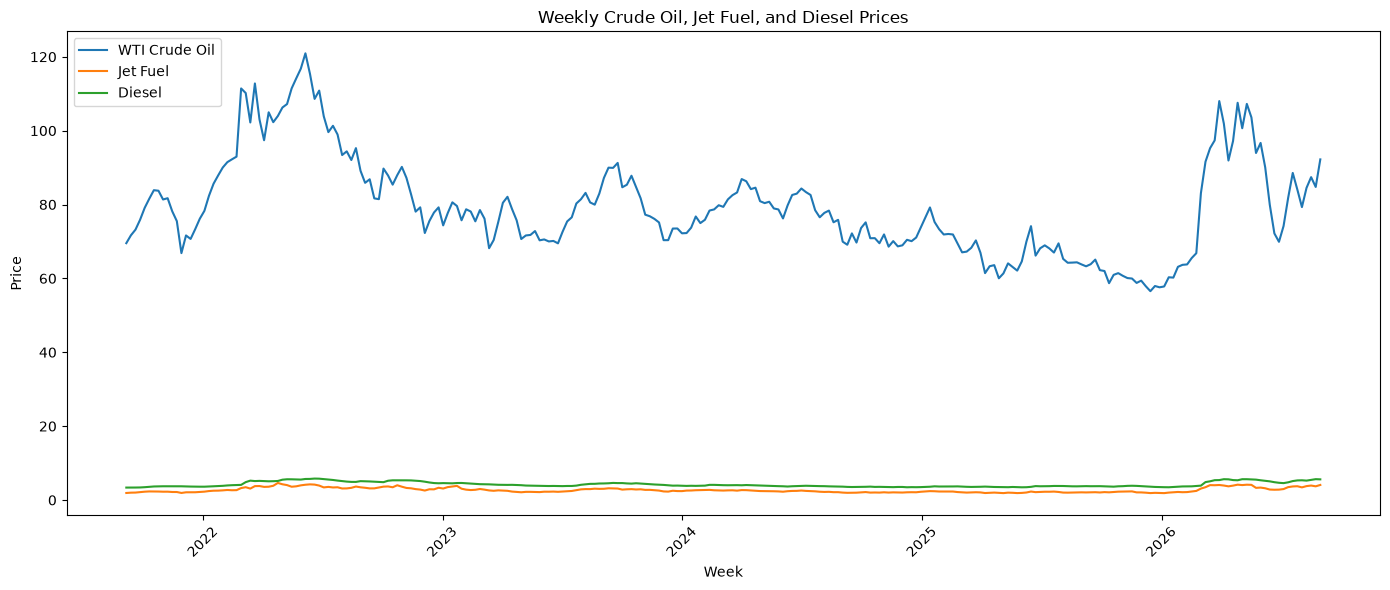

In [83]:
plt.figure(figsize=(14, 6))

plt.plot(
    analytical_df["week"],
    analytical_df["wti_mean"],
    label="WTI Crude Oil"
)

plt.plot(
    analytical_df["week"],
    analytical_df["jet_fuel_weekly"],
    label="Jet Fuel"
)

plt.plot(
    analytical_df["week"],
    analytical_df["diesel_weekly_price"],
    label="Diesel"
)

plt.title("Weekly Crude Oil, Jet Fuel, and Diesel Prices")
plt.xlabel("Week")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Indexed Price Comparison

Because crude oil, jet fuel, and diesel prices have different price scales,
we convert each series to an index where the first observation equals 100.

This allows us to compare the relative movement of the three prices over time.

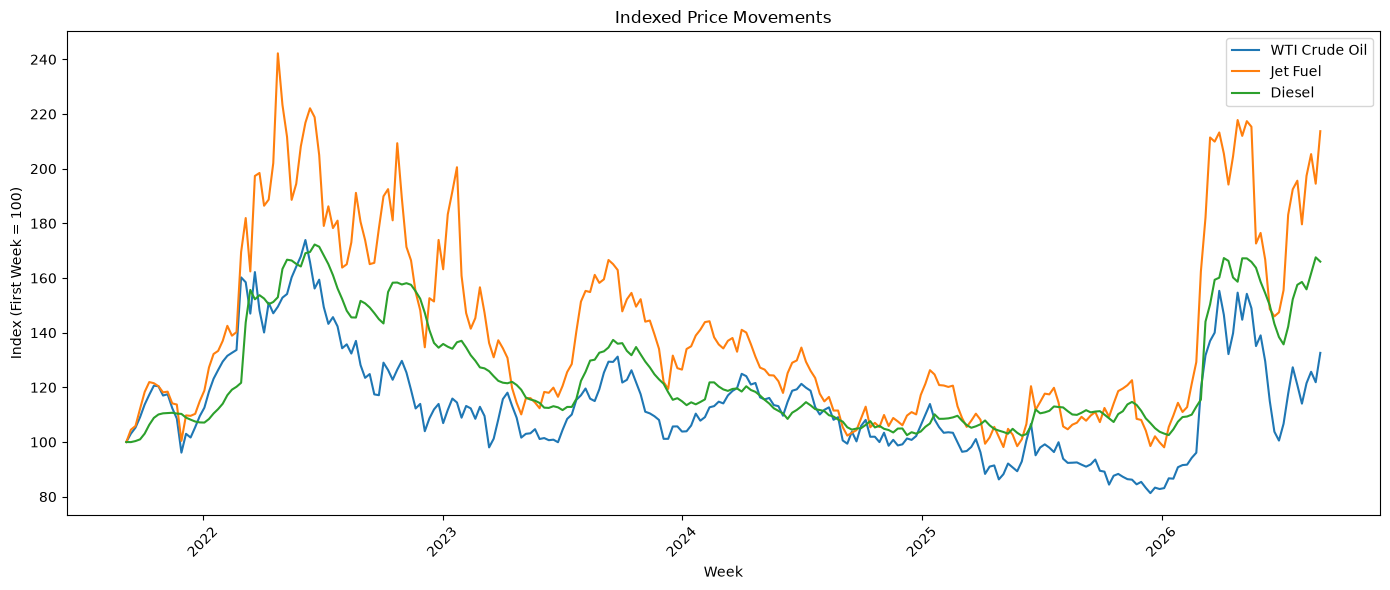

In [84]:
indexed_prices = analytical_df[
    ["week", "wti_mean", "jet_fuel_weekly", "diesel_weekly_price"]
].copy()

for column in ["wti_mean", "jet_fuel_weekly", "diesel_weekly_price"]:
    indexed_prices[column] = (
        indexed_prices[column] / indexed_prices[column].iloc[0]
    ) * 100

plt.figure(figsize=(14, 6))

plt.plot(
    indexed_prices["week"],
    indexed_prices["wti_mean"],
    label="WTI Crude Oil"
)

plt.plot(
    indexed_prices["week"],
    indexed_prices["jet_fuel_weekly"],
    label="Jet Fuel"
)

plt.plot(
    indexed_prices["week"],
    indexed_prices["diesel_weekly_price"],
    label="Diesel"
)

plt.title("Indexed Price Movements")
plt.xlabel("Week")
plt.ylabel("Index (First Week = 100)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.4 Distribution of Fuel Prices

We examine the distribution of crude oil, jet fuel, and diesel prices to
understand their typical values, spread, and possible extreme observations.

WTI

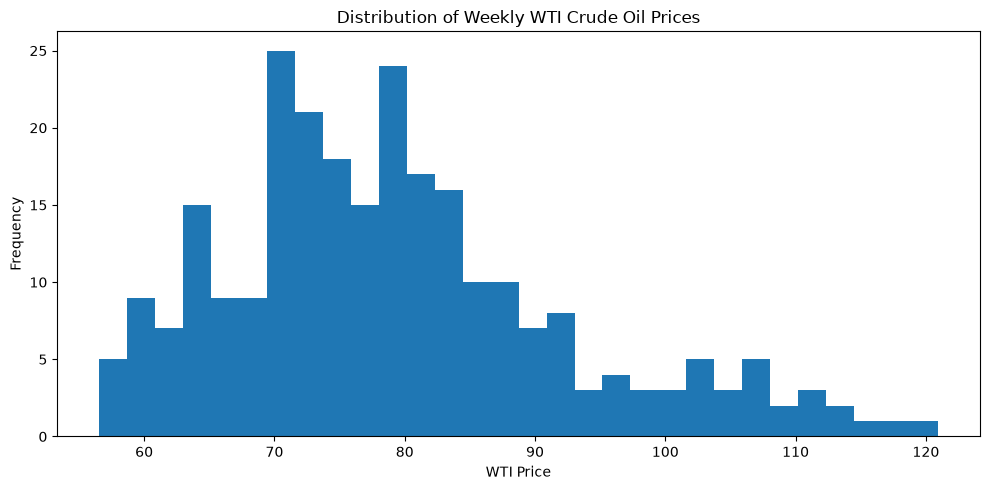

In [85]:
plt.figure(figsize=(10, 5))

plt.hist(analytical_df["wti_mean"], bins=30)

plt.title("Distribution of Weekly WTI Crude Oil Prices")
plt.xlabel("WTI Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Jetfuel

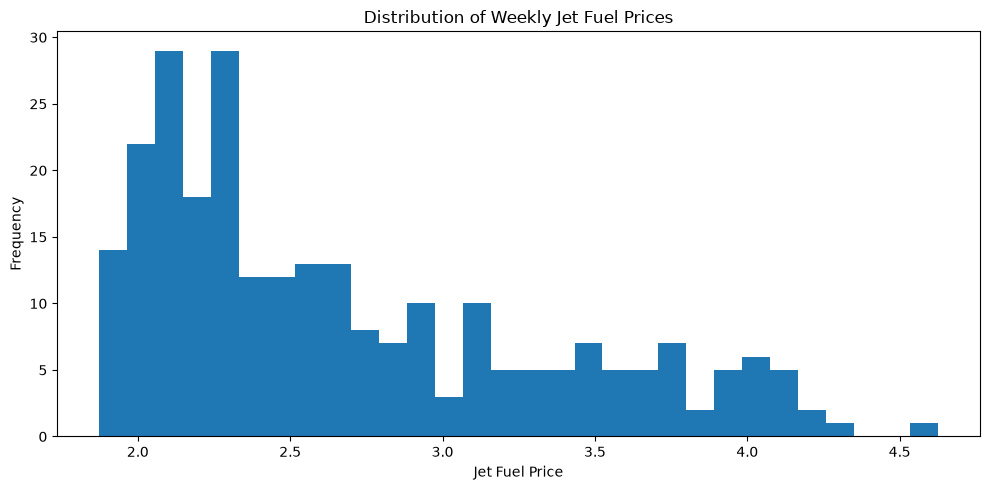

In [86]:
plt.figure(figsize=(10, 5))

plt.hist(analytical_df["jet_fuel_weekly"], bins=30)

plt.title("Distribution of Weekly Jet Fuel Prices")
plt.xlabel("Jet Fuel Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Diesel

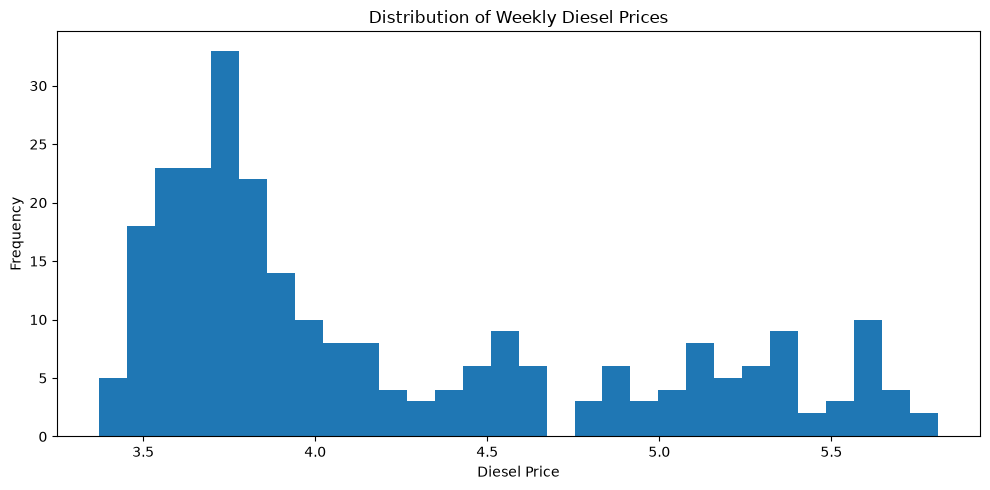

In [88]:
plt.figure(figsize=(10, 5))

plt.hist(analytical_df["diesel_weekly_price"], bins=30)

plt.title("Distribution of Weekly Diesel Prices")
plt.xlabel("Diesel Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 6.5 Boxplots

Boxplots are used to examine the spread of each fuel-price variable and
identify observations that may be unusually high or low compared with the
rest of the dataset.

An unusual observation will not automatically be treated as an error.
Extreme prices may represent genuine market conditions.

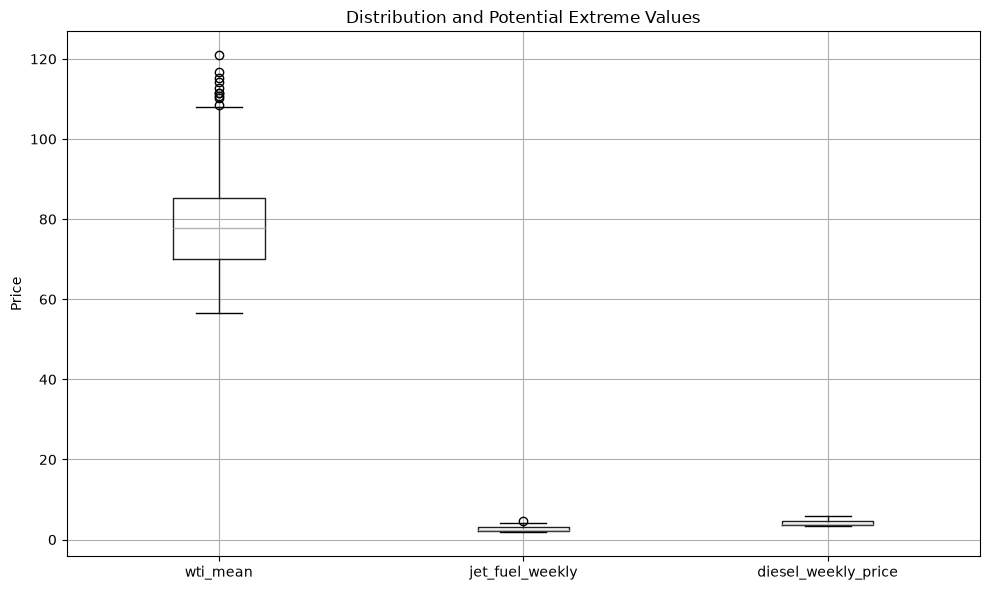

In [89]:
plt.figure(figsize=(10, 6))

analytical_df[
    ["wti_mean", "jet_fuel_weekly", "diesel_weekly_price"]
].boxplot()

plt.title("Distribution and Potential Extreme Values")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

### 6.6 Correlation Analysis

Correlation analysis is used to measure the strength and direction of the
linear relationship between crude oil, jet fuel, and diesel prices.

A positive correlation indicates that two variables tend to increase or
decrease together, while a negative correlation indicates that they tend to
move in opposite directions.

Correlation does not establish causation.

In [90]:
correlation_matrix = analytical_df[
    [
        "wti_mean",
        "jet_fuel_weekly",
        "diesel_weekly_price"
    ]
].corr()

correlation_matrix

,wti_mean,jet_fuel_weekly,diesel_weekly_price
wti_mean,1.000000,0.849424,0.788215
jet_fuel_weekly,0.849424,1.000000,0.931661
diesel_weekly_price,0.788215,0.931661,1.000000


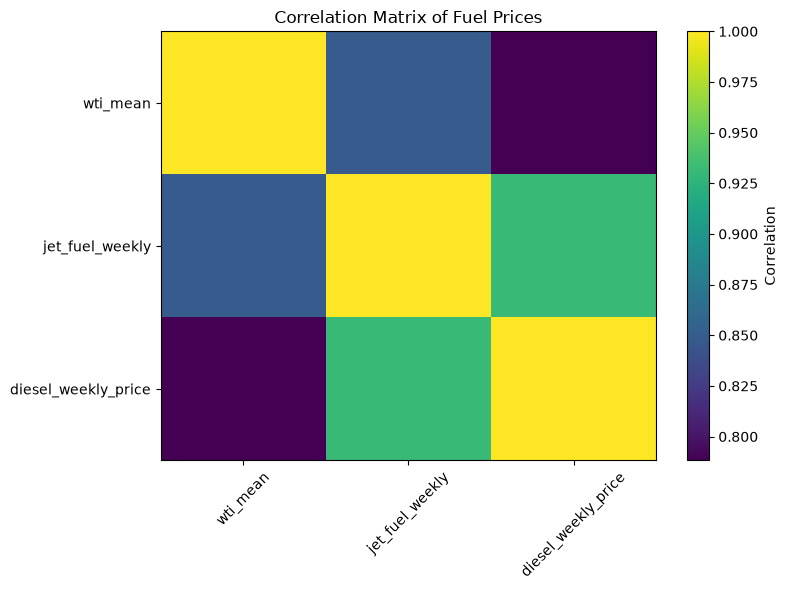

In [91]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Correlation Matrix of Fuel Prices")

plt.tight_layout()
plt.show()

### 6.7 Relationship Between Crude Oil and Jet Fuel Prices

Jet fuel is a refined petroleum product, while WTI represents crude oil.

We examine their relationship to determine whether changes in crude oil prices
are associated with changes in jet fuel prices in our dataset.

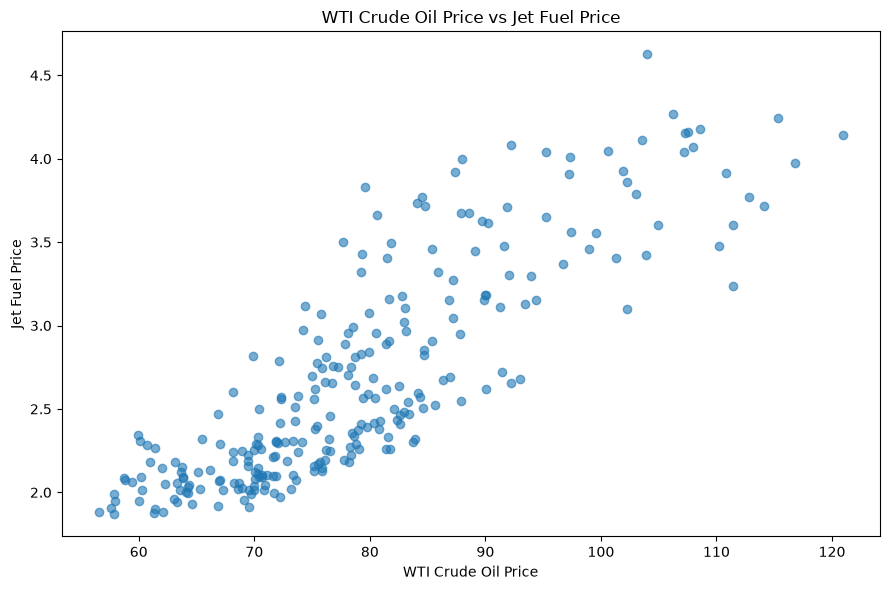

In [93]:
plt.figure(figsize=(9, 6))

plt.scatter(
    analytical_df["wti_mean"],
    analytical_df["jet_fuel_weekly"],
    alpha=0.6
)

plt.title("WTI Crude Oil Price vs Jet Fuel Price")
plt.xlabel("WTI Crude Oil Price")
plt.ylabel("Jet Fuel Price")

plt.tight_layout()
plt.show()

### Relationship Between Crude Oil and Diesel Prices

We examine the relationship between crude oil prices and diesel prices to
determine whether higher crude oil prices are associated with higher diesel
prices.

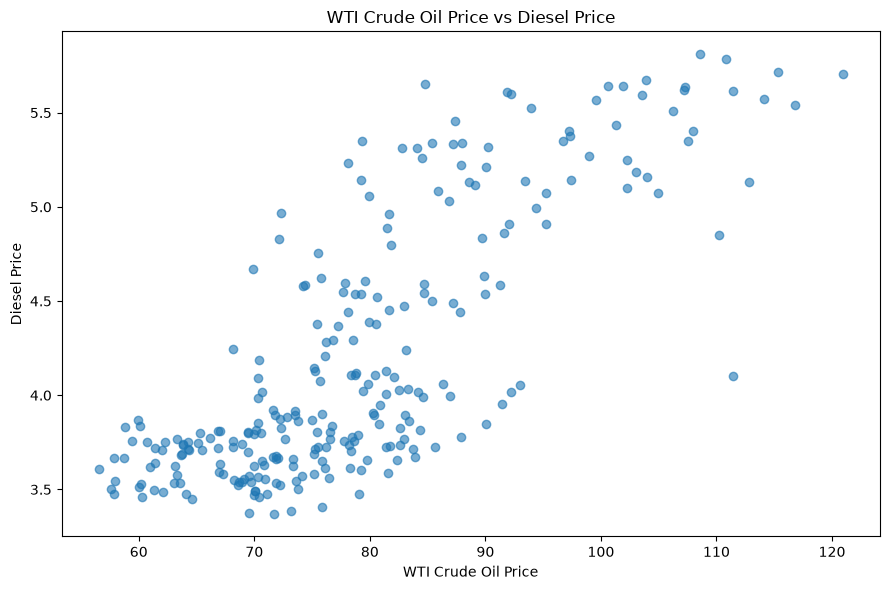

In [95]:
plt.figure(figsize=(9, 6))

plt.scatter(
    analytical_df["wti_mean"],
    analytical_df["diesel_weekly_price"],
    alpha=0.6
)

plt.title("WTI Crude Oil Price vs Diesel Price")
plt.xlabel("WTI Crude Oil Price")
plt.ylabel("Diesel Price")

plt.tight_layout()
plt.show()

### Relationship Between Jet Fuel and Diesel Prices

We examine whether jet fuel and diesel prices tend to move together over
time.

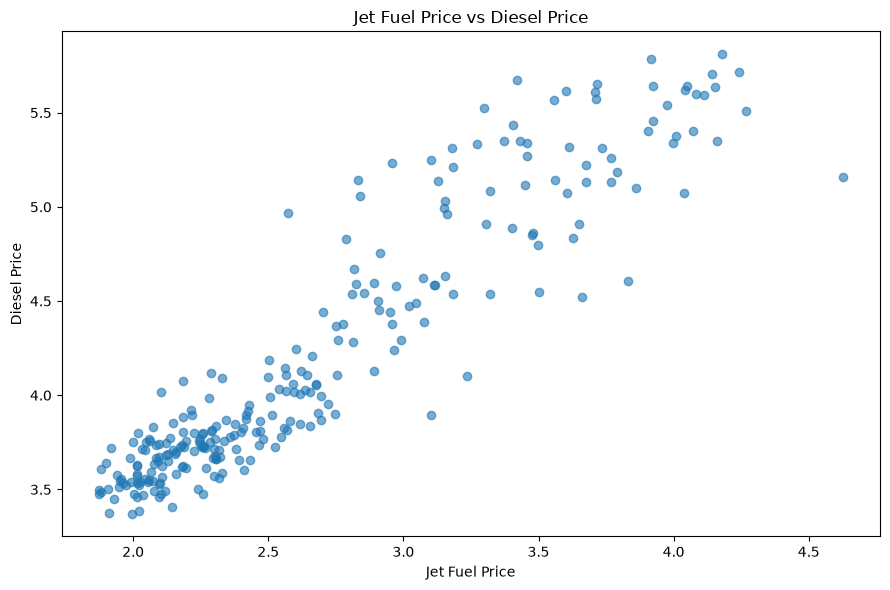

In [96]:
plt.figure(figsize=(9, 6))

plt.scatter(
    analytical_df["jet_fuel_weekly"],
    analytical_df["diesel_weekly_price"],
    alpha=0.6
)

plt.title("Jet Fuel Price vs Diesel Price")
plt.xlabel("Jet Fuel Price")
plt.ylabel("Diesel Price")

plt.tight_layout()
plt.show()

### 6.8 Weekly Price Changes

We calculate the week-to-week percentage change for crude oil, jet fuel, and
diesel prices.

This helps us understand short-term price movements and volatility.

In [100]:
price_change_df = analytical_df[
    ["week", "wti_mean", "jet_fuel_weekly", "diesel_weekly_price"]
].copy()

price_change_df["wti_pct_change"] = (
    price_change_df["wti_mean"].pct_change() * 100
)

price_change_df["jet_fuel_pct_change"] = (
    price_change_df["jet_fuel_weekly"].pct_change() * 100
)

price_change_df["diesel_pct_change"] = (
    price_change_df["diesel_weekly_price"].pct_change() * 100
)

price_change_df.head()

,week,wti_mean,jet_fuel_weekly,diesel_weekly_price,wti_pct_change,jet_fuel_pct_change,diesel_pct_change
0,2021-09-06,69.540,1.910,3.373,NaN,NaN,NaN
1,2021-09-13,71.662,1.996,3.372,3.051481,4.502618,-0.029647
2,2021-09-20,73.206,2.022,3.385,2.154559,1.302605,0.385528
3,2021-09-27,75.882,2.143,3.406,3.655438,5.984174,0.620384
4,2021-10-04,79.096,2.260,3.477,4.235524,5.459636,2.084557


### Weekly Price Change Trends

We visualize weekly percentage changes to identify periods of unusually large
price movements.

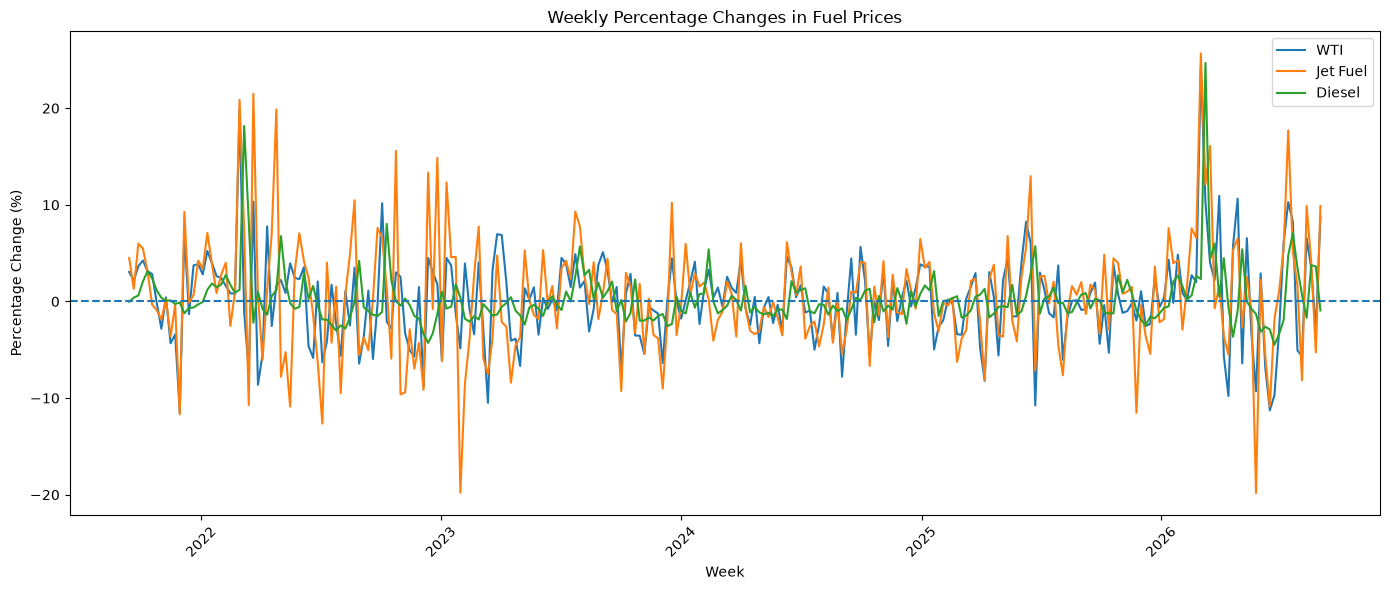

In [101]:
plt.figure(figsize=(14, 6))

plt.plot(
    price_change_df["week"],
    price_change_df["wti_pct_change"],
    label="WTI"
)

plt.plot(
    price_change_df["week"],
    price_change_df["jet_fuel_pct_change"],
    label="Jet Fuel"
)

plt.plot(
    price_change_df["week"],
    price_change_df["diesel_pct_change"],
    label="Diesel"
)

plt.axhline(0, linestyle="--")

plt.title("Weekly Percentage Changes in Fuel Prices")
plt.xlabel("Week")
plt.ylabel("Percentage Change (%)")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 6.9 Weekly Price Volatility

We compare the standard deviation of weekly percentage changes to determine
which fuel-price series experiences greater short-term variation.

In [102]:
volatility = price_change_df[
    [
        "wti_pct_change",
        "jet_fuel_pct_change",
        "diesel_pct_change"
    ]
].std()

volatility

wti_pct_change         4.662435
jet_fuel_pct_change    6.117629
diesel_pct_change      2.765261
dtype: float64

### 6.10 Rolling Average Analysis

We calculate a four-week rolling average for each fuel-price variable.

The rolling average smooths short-term fluctuations and helps reveal the
underlying price trend.

In [103]:
rolling_df = analytical_df[
    ["week", "wti_mean", "jet_fuel_weekly", "diesel_weekly_price"]
].copy()

rolling_df["wti_4week_ma"] = (
    rolling_df["wti_mean"].rolling(window=4).mean()
)

rolling_df["jet_fuel_4week_ma"] = (
    rolling_df["jet_fuel_weekly"].rolling(window=4).mean()
)

rolling_df["diesel_4week_ma"] = (
    rolling_df["diesel_weekly_price"].rolling(window=4).mean()
)

rolling_df.tail()

,week,wti_mean,jet_fuel_weekly,diesel_weekly_price,wti_4week_ma,jet_fuel_4week_ma,diesel_4week_ma
256,2026-08-03,79.3040,3.431,5.348,83.428000,3.58500,5.14775
257,2026-08-10,84.5080,3.770,5.257,84.104500,3.65325,5.26300
258,2026-08-17,87.4120,3.922,5.454,83.819000,3.71475,5.34300
259,2026-08-24,84.7540,3.715,5.652,83.994500,3.70950,5.42775
260,2026-08-31,92.2175,4.082,5.599,87.222875,3.87225,5.49050


### Jet Fuel Price Trend and Rolling Average

We compare the actual weekly jet fuel price with its four-week moving
average to observe short-term fluctuations around the broader trend.

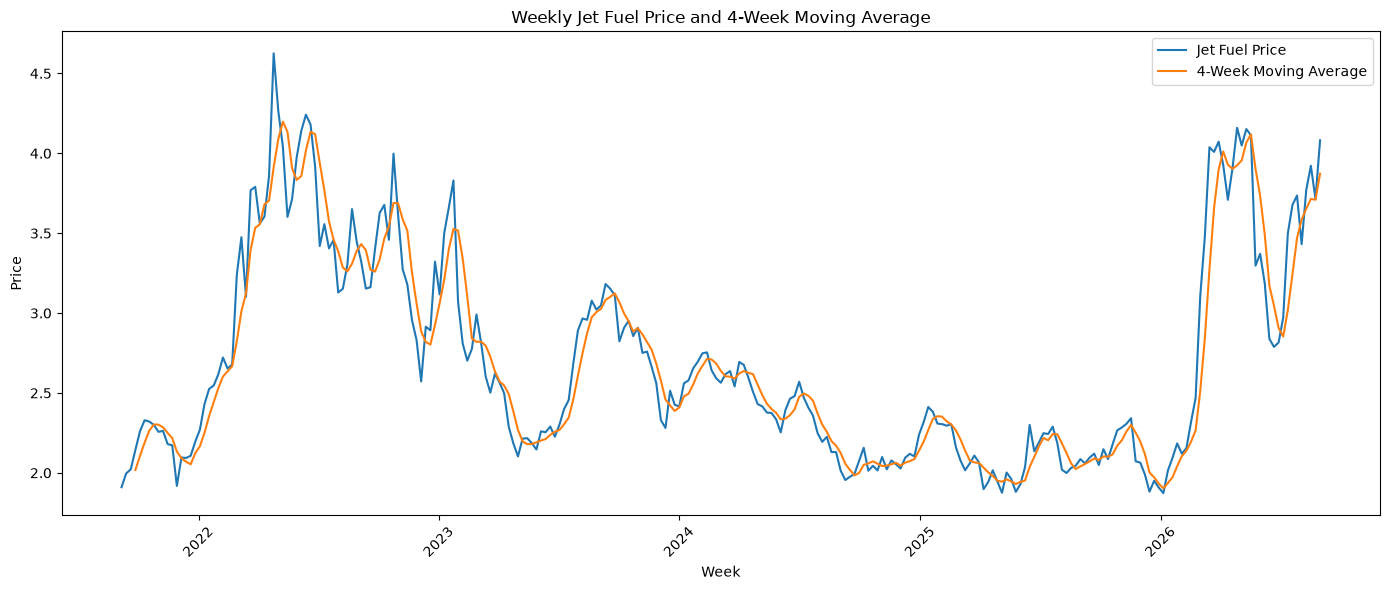

In [104]:
plt.figure(figsize=(14, 6))

plt.plot(
    rolling_df["week"],
    rolling_df["jet_fuel_weekly"],
    label="Jet Fuel Price"
)

plt.plot(
    rolling_df["week"],
    rolling_df["jet_fuel_4week_ma"],
    label="4-Week Moving Average"
)

plt.title("Weekly Jet Fuel Price and 4-Week Moving Average")
plt.xlabel("Week")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 6.11 Lagged Correlation Analysis

The previous analysis examined relationships between fuel prices during the
same week.

For forecasting, we are more interested in whether earlier observations can
help explain future fuel prices.

We therefore examine lagged correlations between WTI crude oil and refined
fuel prices.

A lag of 1 week means that the previous week's WTI price is compared with the
current week's fuel price. Larger lags allow us to investigate whether crude
oil price movements are reflected in refined fuel prices after several weeks.

This analysis measures association and does not by itself establish causation.

In [108]:
lag_analysis = analytical_df[
    ["week", "wti_mean", "jet_fuel_weekly", "diesel_weekly_price"]
].copy()

for lag in range(0, 9):
    lag_analysis[f"wti_lag_{lag}"] = (
        lag_analysis["wti_mean"].shift(lag)
    )

lag_correlations = []

for lag in range(0, 9):
    lag_correlations.append({
        "lag_weeks": lag,
        "WTI_vs_Jet_Fuel_weekly": lag_analysis[
            [f"wti_lag_{lag}", "jet_fuel_weekly"]
        ].corr().iloc[0, 1],
        "WTI_vs_Diesel_weekly": lag_analysis[
            [f"wti_lag_{lag}", "diesel_weekly_price"]
        ].corr().iloc[0, 1]
    })

lag_correlations_df = pd.DataFrame(lag_correlations)

lag_correlations_df

,lag_weeks,WTI_vs_Jet_Fuel_weekly,WTI_vs_Diesel_weekly
0,0,0.849424,0.788215
1,1,0.819686,0.817599
2,2,0.783839,0.816962
3,3,0.748655,0.796983
4,4,0.708216,0.773477
5,5,0.675325,0.750051
6,6,0.646950,0.720856
7,7,0.612194,0.687314
8,8,0.577786,0.657670


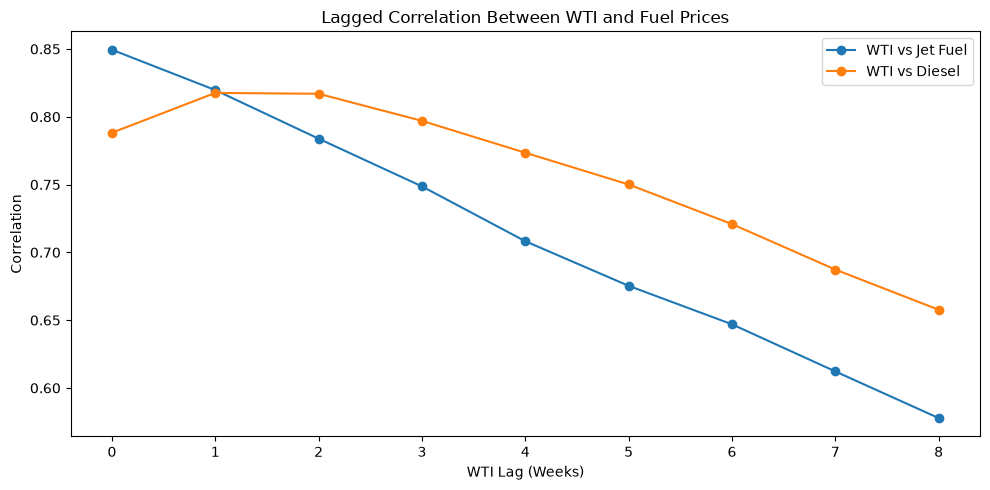

In [109]:
plt.figure(figsize=(10, 5))

plt.plot(
    lag_correlations_df["lag_weeks"],
    lag_correlations_df["WTI_vs_Jet_Fuel_weekly"],
    marker="o",
    label="WTI vs Jet Fuel"
)

plt.plot(
    lag_correlations_df["lag_weeks"],
    lag_correlations_df["WTI_vs_Diesel_weekly"],
    marker="o",
    label="WTI vs Diesel"
)

plt.xlabel("WTI Lag (Weeks)")
plt.ylabel("Correlation")
plt.title("Lagged Correlation Between WTI and Fuel Prices")
plt.xticks(range(0, 9))
plt.legend()

plt.tight_layout()
plt.show()

### 6.12 Exploratory Data Analysis Summary

The exploratory data analysis provided several important insights into the
behavior and relationships of crude oil, jet fuel, and diesel prices over the
study period.

#### Key Findings

1. **Fuel prices show clear long-term trends and periods of volatility.**
   WTI crude oil, jet fuel, and diesel prices generally move in the same broad
   direction, with notable periods of rapid price increases and decreases.
   Jet fuel shows particularly large movements during high-price periods.

2. **Jet fuel prices are more volatile than diesel prices.**
   Weekly percentage changes show that jet fuel experiences larger short-term
   fluctuations, while diesel prices generally exhibit smoother week to week
   movements. This difference is important because FedEx's air and ground
   operations may experience different fuel-price dynamics.

3. **Jet fuel and diesel prices have a strong positive relationship.**
   Higher jet fuel prices generally occur alongside higher diesel prices.
   However, the relationship becomes more variable during higher-price
   periods, suggesting that the two refined fuel markets do not move in
   exactly the same way.

4. **Crude oil prices are strongly associated with refined fuel prices.**
   WTI has a strong positive relationship with both jet fuel and diesel prices.
   The relationship with jet fuel is relatively strong and continuous, while
   diesel shows greater variation at different crude-oil price levels.

5. **The fuel-price variables are highly correlated.**
   The correlation analysis shows strong positive relationships between WTI,
   jet fuel, and diesel prices. This indicates potential multicollinearity if
   all variables are included together as unlagged predictors in linear
   models. Feature selection, lagged variables, or regularized models may
   therefore be useful during the modeling stage.

6. **Fuel prices contain outliers potentially meaningful observations.**
   The distributions and boxplots show periods of unusually high prices,
   particularly for WTI and jet fuel. These observations should not
   automatically be removed because they may represent genuine market
   conditions that a forecasting model should be able to handle.

7. **Jet fuel prices are right-skewed.**
   Most observations occur at relatively lower price levels, while a smaller
   number of high-price observations form a long upper tail. This indicates
   that forecasting methods should be evaluated carefully during periods of
   extreme price movements.

8. **Rolling averages reveal broader market trends.**
   The four-week moving average successfully smooths short-term fluctuations
   and makes longer-term price movements easier to identify. It may therefore
   be useful as a candidate feature during feature engineering.

9. **Lag analysis reveals different timing relationships.**
   Jet fuel has its strongest observed relationship with WTI at Lag 0,
   with a correlation of approximately 0.85. Diesel has a lower
   correlation of approximately 0.79 but reaches its highest observed correlation
   around the 1- to 2-week lag at approximately 0.82.
   This suggests that crude-oil movements may be reflected in different fuel
   markets over different time horizons.

#### Implications for the Forecasting Stage

The EDA suggests that crude oil, jet fuel, and diesel prices contain useful
information for forecasting future fuel prices. However, correlation alone
does not show causation, and existing relationships cannot
automatically be used as forecasting features.

The next stage will therefore focus on feature engineering using information
that would have been available before the forecast period. Possible features
will include lagged fuel prices, rolling averages, price changes, and
volatility measures.

The final forecasting dataset will be constructed carefully to avoid
data leakage, with the target representing the **following week's fuel
price**.

The current analysis focuses on fuel-price behavior. Historical FedEx fuel
consumption and operational data will be required separately before a model
for actual FedEx fuel consumption can be developed.

## 7 Feature Engineering
### 7.1 Create the Forecasting Dataset

The objective is to predict the following week's fuel price.

A separate forecasting dataset is created from the analytical dataset so that
the original EDA dataset remains unchanged.

The forecasting target will represent the fuel price observed one week after
the current observation.

In [110]:
forecast_df = analytical_df.copy()

forecast_df = forecast_df.sort_values("week").reset_index(drop=True)

print("Forecasting dataset shape:", forecast_df.shape)
forecast_df.head()

Forecasting dataset shape: (261, 11)


,week,wti_mean,wti_min,wti_max,wti_std,jet_daily_mean,jet_daily_min,jet_daily_max,jet_daily_std,jet_fuel_weekly,diesel_weekly_price
0,2021-09-06,69.540,68.26,70.54,1.165504,1.923333,1.893,1.955,0.031021,1.910,3.373
1,2021-09-13,71.662,70.41,72.69,1.112439,1.999000,1.965,2.022,0.028080,1.996,3.372
2,2021-09-20,73.206,70.51,75.54,1.898270,2.050400,1.989,2.115,0.050198,2.022,3.385
3,2021-09-27,75.882,75.06,77.68,1.067530,2.176400,2.105,2.284,0.070882,2.143,3.406
4,2021-10-04,79.096,77.66,80.64,1.124958,2.265400,2.220,2.309,0.032393,2.260,3.477


### 7.2 Create the Next-Week Jet Fuel Price Target

The target variable is the jet fuel price in the following week.

The `shift(-1)` operation moves the following week's jet fuel price onto the
current week's row.

For example, the observation for Week 1 will contain the jet fuel price from
Week 2 as its forecasting target.

This allows the model to learn how current and historical information relates
to future jet fuel prices.

In [113]:
forecast_df["next_week_jet_fuel_price"] = (
    forecast_df["jet_fuel_weekly"].shift(-1)
)

forecast_df[
    [
        "week",
        "jet_fuel_weekly",
        "next_week_jet_fuel_price"
    ]
].head(10)

,week,jet_fuel_weekly,next_week_jet_fuel_price
0,2021-09-06,1.910,1.996
1,2021-09-13,1.996,2.022
2,2021-09-20,2.022,2.143
3,2021-09-27,2.143,2.260
4,2021-10-04,2.260,2.329
5,2021-10-11,2.329,2.321
6,2021-10-18,2.321,2.300
7,2021-10-25,2.300,2.257
8,2021-11-01,2.257,2.262
9,2021-11-08,2.262,2.180


In [114]:
print(
    "Missing values in target:",
    forecast_df["next_week_jet_fuel_price"].isna().sum()
)

Missing values in target: 1


### 7.3 WTI Lag Features

Lagged variables contain historical observations from previous weeks.

The following WTI lags will be created:

- 1-week lag
- 2-week lag
- 4-week lag
- 8-week lag

These features allow the forecasting models to learn whether previous crude oil
prices contain useful information for predicting the following week's jet fuel
price.

In [115]:
wti_lags = [1, 2, 4, 8]

for lag in wti_lags:
    forecast_df[f"wti_lag_{lag}"] = (
        forecast_df["wti_mean"].shift(lag)
    )

forecast_df[
    [
        "week",
        "wti_mean",
        "wti_lag_1",
        "wti_lag_2",
        "wti_lag_4",
        "wti_lag_8"
    ]
].head(12)

,week,wti_mean,wti_lag_1,wti_lag_2,wti_lag_4,wti_lag_8
0,2021-09-06,69.540000,NaN,NaN,NaN,NaN
1,2021-09-13,71.662000,69.540,NaN,NaN,NaN
2,2021-09-20,73.206000,71.662,69.540,NaN,NaN
3,2021-09-27,75.882000,73.206,71.662,NaN,NaN
4,2021-10-04,79.096000,75.882,73.206,69.540,NaN
5,2021-10-11,81.572000,79.096,75.882,71.662,NaN
6,2021-10-18,83.880000,81.572,79.096,73.206,NaN
7,2021-10-25,83.732000,83.880,81.572,75.882,NaN
8,2021-11-01,81.364000,83.732,83.880,79.096,69.540
9,2021-11-08,81.708000,81.364,83.732,81.572,71.662


### 7.4 Jet Fuel Lag Features

Historical jet fuel prices are included as lagged features.

Previous 1-week, 2-week, 4-week, and 8-week jet fuel prices will be used as
candidate predictors.

These features allow the model to capture short-term persistence and longer
historical price patterns.

In [116]:
jet_lags = [1, 2, 4, 8]

for lag in jet_lags:
    forecast_df[f"jet_fuel_lag_{lag}"] = (
        forecast_df["jet_fuel_weekly"].shift(lag)
    )

forecast_df[
    [
        "week",
        "jet_fuel_weekly",
        "jet_fuel_lag_1",
        "jet_fuel_lag_2",
        "jet_fuel_lag_4",
        "jet_fuel_lag_8"
    ]
].head(12)

,week,jet_fuel_weekly,jet_fuel_lag_1,jet_fuel_lag_2,jet_fuel_lag_4,jet_fuel_lag_8
0,2021-09-06,1.910,NaN,NaN,NaN,NaN
1,2021-09-13,1.996,1.910,NaN,NaN,NaN
2,2021-09-20,2.022,1.996,1.910,NaN,NaN
3,2021-09-27,2.143,2.022,1.996,NaN,NaN
4,2021-10-04,2.260,2.143,2.022,1.910,NaN
5,2021-10-11,2.329,2.260,2.143,1.996,NaN
6,2021-10-18,2.321,2.329,2.260,2.022,NaN
7,2021-10-25,2.300,2.321,2.329,2.143,NaN
8,2021-11-01,2.257,2.300,2.321,2.260,1.910
9,2021-11-08,2.262,2.257,2.300,2.329,1.996


### 7.5 Diesel Lag Features

Historical diesel prices are included as candidate predictors.

Although the primary forecasting target is jet fuel price, diesel prices may
provide additional information about broader refined-fuel market conditions.

Lagged diesel prices from 1, 2, 4, and 8 weeks earlier are therefore created.

In [118]:
diesel_lags = [1, 2, 4, 8]

for lag in diesel_lags:
    forecast_df[f"diesel_lag_{lag}"] = (
        forecast_df["diesel_weekly_price"].shift(lag)
    )

forecast_df[
    [
        "week",
        "diesel_weekly_price",
        "diesel_lag_1",
        "diesel_lag_2",
        "diesel_lag_4",
        "diesel_lag_8"
    ]
].head(12)

,week,diesel_weekly_price,diesel_lag_1,diesel_lag_2,diesel_lag_4,diesel_lag_8
0,2021-09-06,3.373,NaN,NaN,NaN,NaN
1,2021-09-13,3.372,3.373,NaN,NaN,NaN
2,2021-09-20,3.385,3.372,3.373,NaN,NaN
3,2021-09-27,3.406,3.385,3.372,NaN,NaN
4,2021-10-04,3.477,3.406,3.385,3.373,NaN
5,2021-10-11,3.586,3.477,3.406,3.372,NaN
6,2021-10-18,3.671,3.586,3.477,3.385,NaN
7,2021-10-25,3.713,3.671,3.586,3.406,NaN
8,2021-11-01,3.727,3.713,3.671,3.477,3.373
9,2021-11-08,3.730,3.727,3.713,3.586,3.372


### 7.6 Rolling Mean Features

Rolling averages are used to represent the recent underlying price trend.

Four-week and eight-week rolling averages will be calculated for WTI, jet fuel,
and diesel.

The rolling calculations are shifted by one week so that the current week's
price is not included in the historical feature information.

This prevents future-information leakage when predicting the next week's price.

In [120]:
rolling_variables = {
    "wti_mean": "wti",
    "jet_fuel_weekly": "jet_fuel",
    "diesel_weekly_price": "diesel"
}

for column, prefix in rolling_variables.items():
    forecast_df[f"{prefix}_4week_ma"] = (
        forecast_df[column]
        .shift(1)
        .rolling(window=4)
        .mean()
    )

    forecast_df[f"{prefix}_8week_ma"] = (
        forecast_df[column]
        .shift(1)
        .rolling(window=8)
        .mean()
    )

forecast_df[
    [
        "week",
        "wti_4week_ma",
        "wti_8week_ma",
        "jet_fuel_4week_ma",
        "jet_fuel_8week_ma",
        "diesel_4week_ma",
        "diesel_8week_ma"
    ]
].head(12)

,week,wti_4week_ma,wti_8week_ma,jet_fuel_4week_ma,jet_fuel_8week_ma,diesel_4week_ma,diesel_8week_ma
0,2021-09-06,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-09-13,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-09-20,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-09-27,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-10-04,72.5725,NaN,2.01775,NaN,3.38400,NaN
5,2021-10-11,74.9615,NaN,2.10525,NaN,3.41000,NaN
6,2021-10-18,77.4390,NaN,2.18850,NaN,3.46350,NaN
7,2021-10-25,80.1075,NaN,2.26325,NaN,3.53500,NaN
8,2021-11-01,82.0700,77.32125,2.30250,2.160125,3.61175,3.497875
9,2021-11-08,82.6370,78.79925,2.30175,2.203500,3.67425,3.542125


### 7.7 Weekly Price Change Features

Weekly percentage changes are created to represent short-term price momentum.

These features measure how much the price changed relative to the previous
week.

They are calculated from historical observations and can therefore be used as
candidate forecasting features.

In [121]:
forecast_df["wti_pct_change"] = (
    forecast_df["wti_mean"].pct_change()
)

forecast_df["jet_fuel_pct_change"] = (
    forecast_df["jet_fuel_weekly"].pct_change()
)

forecast_df["diesel_pct_change"] = (
    forecast_df["diesel_weekly_price"].pct_change()
)

forecast_df[
    [
        "week",
        "wti_pct_change",
        "jet_fuel_pct_change",
        "diesel_pct_change"
    ]
].head(10)

,week,wti_pct_change,jet_fuel_pct_change,diesel_pct_change
0,2021-09-06,NaN,NaN,NaN
1,2021-09-13,0.030515,0.045026,-0.000296
2,2021-09-20,0.021546,0.013026,0.003855
3,2021-09-27,0.036554,0.059842,0.006204
4,2021-10-04,0.042355,0.054596,0.020846
5,2021-10-11,0.031304,0.030531,0.031349
6,2021-10-18,0.028294,-0.003435,0.023703
7,2021-10-25,-0.001764,-0.009048,0.011441
8,2021-11-01,-0.028281,-0.018696,0.003771
9,2021-11-08,0.004228,0.002215,0.000805


### 7.8 Rolling Volatility Features

Rolling standard deviation is used to measure recent price volatility.

A four-week rolling standard deviation is calculated for WTI, jet fuel, and
diesel.

The calculation is shifted by one week to ensure that the feature only uses
historical observations when predicting the next week's price.

In [122]:
forecast_df["wti_4week_volatility"] = (
    forecast_df["wti_mean"]
    .shift(1)
    .rolling(window=4)
    .std()
)

forecast_df["jet_fuel_4week_volatility"] = (
    forecast_df["jet_fuel_weekly"]
    .shift(1)
    .rolling(window=4)
    .std()
)

forecast_df["diesel_4week_volatility"] = (
    forecast_df["diesel_weekly_price"]
    .shift(1)
    .rolling(window=4)
    .std()
)

### 7.9 Feature Engineering Check

The engineered dataset is inspected to verify that the expected lag,
rolling-average, percentage-change, and volatility features have been created.

Missing values are expected at the beginning of the dataset because lagged and
rolling features require historical observations.

In [123]:
print("Shape:", forecast_df.shape)

print("\nColumns:")
print(forecast_df.columns.tolist())

print("\nMissing values:")
print(forecast_df.isna().sum())

Shape: (261, 36)

Columns:
['week', 'wti_mean', 'wti_min', 'wti_max', 'wti_std', 'jet_daily_mean', 'jet_daily_min', 'jet_daily_max', 'jet_daily_std', 'jet_fuel_weekly', 'diesel_weekly_price', 'next_week_jet_fuel_price', 'wti_lag_1', 'wti_lag_2', 'wti_lag_4', 'wti_lag_8', 'jet_fuel_lag_1', 'jet_fuel_lag_2', 'jet_fuel_lag_4', 'jet_fuel_lag_8', 'diesel_lag_1', 'diesel_lag_2', 'diesel_lag_4', 'diesel_lag_8', 'wti_4week_ma', 'wti_8week_ma', 'jet_fuel_4week_ma', 'jet_fuel_8week_ma', 'diesel_4week_ma', 'diesel_8week_ma', 'wti_pct_change', 'jet_fuel_pct_change', 'diesel_pct_change', 'wti_4week_volatility', 'jet_fuel_4week_volatility', 'diesel_4week_volatility']

Missing values:
week                         0
wti_mean                     0
wti_min                      0
wti_max                      0
wti_std                      0
jet_daily_mean               0
jet_daily_min                0
jet_daily_max                0
jet_daily_std                0
jet_fuel_weekly              0
diesel_week

In [124]:
forecast_df.head(15)

,week,wti_mean,wti_min,wti_max,wti_std,jet_daily_mean,jet_daily_min,jet_daily_max,jet_daily_std,jet_fuel_weekly,diesel_weekly_price,next_week_jet_fuel_price,wti_lag_1,wti_lag_2,wti_lag_4,wti_lag_8,jet_fuel_lag_1,jet_fuel_lag_2,jet_fuel_lag_4,jet_fuel_lag_8,diesel_lag_1,diesel_lag_2,diesel_lag_4,diesel_lag_8,wti_4week_ma,wti_8week_ma,jet_fuel_4week_ma,jet_fuel_8week_ma,diesel_4week_ma,diesel_8week_ma,wti_pct_change,jet_fuel_pct_change,diesel_pct_change,wti_4week_volatility,jet_fuel_4week_volatility,diesel_4week_volatility
0,2021-09-06,69.540000,68.26,70.54,1.165504,1.923333,1.893,1.955,0.031021,1.910,3.373,1.996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-09-13,71.662000,70.41,72.69,1.112439,1.999000,1.965,2.022,0.028080,1.996,3.372,2.022,69.540000,NaN,NaN,NaN,1.910,NaN,NaN,NaN,3.373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.030515,0.045026,-0.000296,NaN,NaN,NaN
2,2021-09-20,73.206000,70.51,75.54,1.898270,2.050400,1.989,2.115,0.050198,2.022,3.385,2.143,71.662000,69.540000,NaN,NaN,1.996,1.910,NaN,NaN,3.372,3.373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.021546,0.013026,0.003855,NaN,NaN,NaN
3,2021-09-27,75.882000,75.06,77.68,1.067530,2.176400,2.105,2.284,0.070882,2.143,3.406,2.260,73.206000,71.662000,NaN,NaN,2.022,1.996,NaN,NaN,3.385,3.372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.036554,0.059842,0.006204,NaN,NaN,NaN
4,2021-10-04,79.096000,77.66,80.64,1.124958,2.265400,2.220,2.309,0.032393,2.260,3.477,2.329,75.882000,73.206000,69.540,NaN,2.143,2.022,1.910,NaN,3.406,3.385,3.373,NaN,72.572500,NaN,2.01775,NaN,3.38400,NaN,0.042355,0.054596,0.020846,2.669530,0.096244,0.015811
5,2021-10-11,81.572000,80.67,82.62,0.905108,2.327800,2.299,2.361,0.030327,2.329,3.586,2.321,79.096000,75.882000,71.662,NaN,2.260,2.143,1.996,NaN,3.477,3.406,3.372,NaN,74.961500,NaN,2.10525,NaN,3.41000,NaN,0.031304,0.030531,0.031349,3.261385,0.121434,0.046812
6,2021-10-18,83.880000,82.64,84.64,0.906118,2.325400,2.312,2.353,0.016456,2.321,3.671,2.300,81.572000,79.096000,73.206,NaN,2.329,2.260,2.022,NaN,3.586,3.477,3.385,NaN,77.439000,NaN,2.18850,NaN,3.46350,NaN,0.028294,-0.003435,0.023703,3.659229,0.134963,0.090659
7,2021-10-25,83.732000,82.66,85.64,1.211495,2.294800,2.271,2.339,0.027096,2.300,3.713,2.257,83.880000,81.572000,75.882,NaN,2.321,2.329,2.143,NaN,3.671,3.586,3.406,NaN,80.107500,NaN,2.26325,NaN,3.53500,NaN,-0.001764,-0.009048,0.011441,3.428046,0.085885,0.117050
8,2021-11-01,81.364000,78.88,83.91,1.824590,2.251800,2.212,2.300,0.036424,2.257,3.727,2.262,83.732000,83.880000,79.096,69.540,2.300,2.321,2.260,1.910,3.713,3.671,3.477,3.373,82.070000,77.321250,2.30250,2.160125,3.61175,3.497875,-0.028281,-0.018696,0.003771,2.245813,0.030860,0.104216
9,2021-11-08,81.708000,80.85,84.12,1.373070,2.249200,2.210,2.319,0.043997,2.262,3.730,2.180,81.364000,83.732000,81.572,71.662,2.257,2.300,2.329,1.996,3.727,3.713,3.586,3.372,82.637000,78.799250,2.30175,2.203500,3.67425,3.542125,0.004228,0.002215,0.000805,1.353862,0.032243,0.063463
